In [ ]:
from google.colab import drive

drive.mount('/content/drive')

path = "/content/drive/MyDrive/LSWMD.pkl/LSWMD.pkl"

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_pickle(path)

df.head()
print(df.shape)
print(df.columns)

(811457, 6)
Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType'],
      dtype='object')


In [ ]:
print(df.head())

print("\n--- dtypes ---")
print(df.dtypes)

print("\n--- failureType samples ---")
for i in range(10):
    print(i, df.iloc[i]["failureType"])

print("\n--- trianTestLabel samples ---")
for i in range(10):
    print(i, df.iloc[i]["trianTestLabel"])

print("\n--- waferMap sample ---")
wafer = df.iloc[0]["waferMap"]
print(type(wafer))
print(wafer.shape)
print(wafer)

                                            waferMap  dieSize lotName  \
0  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
1  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
3  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
4  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   

   waferIndex trianTestLabel failureType  
0         1.0   [[Training]]    [[none]]  
1         2.0   [[Training]]    [[none]]  
2         3.0   [[Training]]    [[none]]  
3         4.0   [[Training]]    [[none]]  
4         5.0   [[Training]]    [[none]]  

--- dtypes ---
waferMap           object
dieSize           float64
lotName            object
waferIndex        float64
trianTestLabel     object
failureType        object
dtype: object

--- failureType samples ---
0 [['none']]
1 [['none']]
2 [['none']]
3 [['none']]
4 [['none']]
5 [['none']]
6 [['none'

In [ ]:
import numpy as np

def extract_label(x):
    arr = np.asarray(x).reshape(-1)

    if len(arr) == 0:
        return None

    value = arr[0]

    if value is None or str(value).strip() == "":
        return None

    return str(value)

df["failure_label"] = df["failureType"].apply(extract_label)
df["split_label"] = df["trianTestLabel"].apply(extract_label)

print(df["failure_label"].value_counts(dropna=False))

failure_label
None         638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


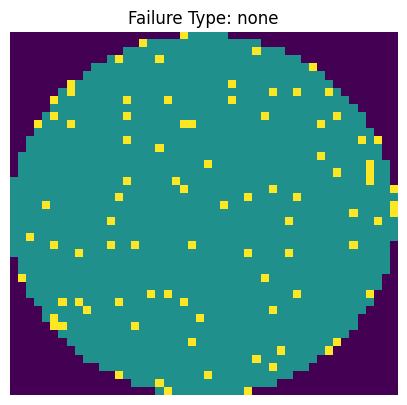

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.imshow(df.iloc[0]["waferMap"])
plt.title(f"Failure Type: {df.iloc[0]['failure_label']}")
plt.axis("off")
plt.show()

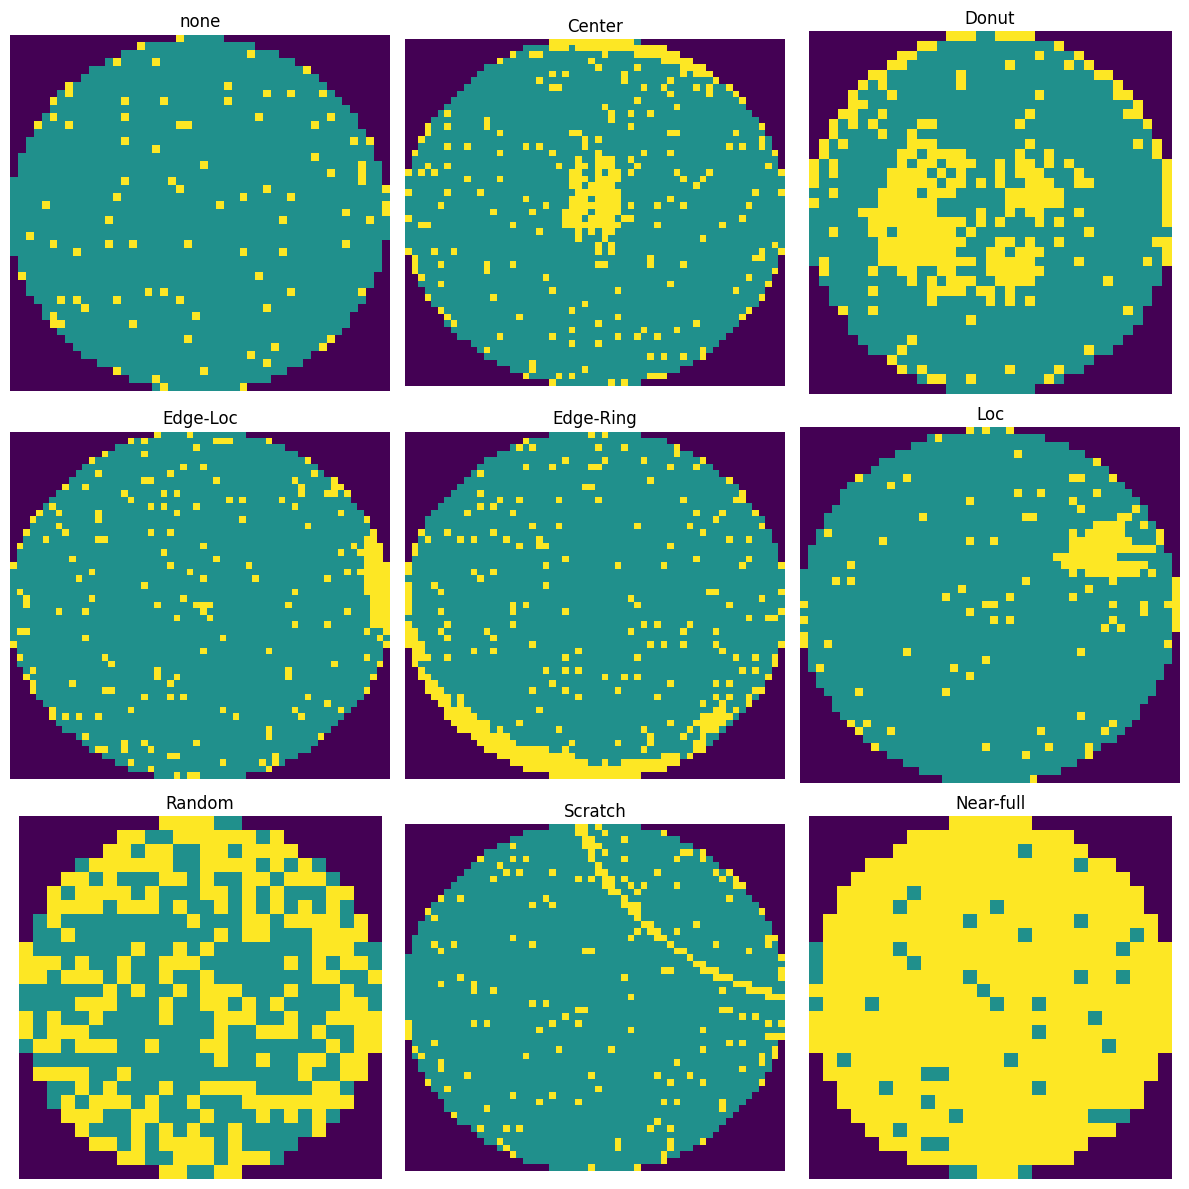

In [ ]:
import matplotlib.pyplot as plt

labels = [
    "none",
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-full"
]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, label in zip(axes.flatten(), labels):
    sample = df[df["failure_label"] == label].iloc[0]

    ax.imshow(sample["waferMap"])
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
labeled_df = df[df["failure_label"].notna()].copy()

print(labeled_df["split_label"].value_counts(dropna=False))

print(
    pd.crosstab(
        labeled_df["failure_label"],
        labeled_df["split_label"],
        margins=True
    )
)

split_label
Test        118595
Training     54355
Name: count, dtype: int64
split_label      Test  Training     All
failure_label                          
Center            832      3462    4294
Donut             146       409     555
Edge-Loc         2772      2417    5189
Edge-Ring        1126      8554    9680
Loc              1973      1620    3593
Near-full          95        54     149
Random            257       609     866
Scratch           693       500    1193
none           110701     36730  147431
All            118595     54355  172950


In [ ]:
print("Number of lots:", df["lotName"].nunique())

print("\nWafers per lot:")
print(df["lotName"].value_counts().describe())

print("\nExample lots:")
print(df["lotName"].value_counts().head(10))

labeled_df = df[df["failure_label"].notna()].copy()

lot_failure = pd.crosstab(
    labeled_df["lotName"],
    labeled_df["failure_label"]
)

print(lot_failure.head())

Number of lots: 46293

Wafers per lot:
count    46293.000000
mean        17.528719
std          8.964477
min          1.000000
25%         10.000000
50%         24.000000
75%         25.000000
max         25.000000
Name: count, dtype: float64

Example lots:
lotName
lot47542    25
lot1        25
lot2        25
lot3        25
lot4        25
lot5        25
lot6        25
lot7        25
lot8        25
lot9        25
Name: count, dtype: int64
failure_label  Center  Donut  Edge-Loc  Edge-Ring  Loc  Near-full  Random  \
lotName                                                                     
lot1                0      0         0          0    1          0       0   
lot10               0      0         0          0    0          0       0   
lot100              0      0         0          0    0          0       0   
lot10006            1      0         0          0    0          0       0   
lot10008            0      0         0         24    0          0       0   

failure_label  Scr

In [ ]:
train_df = labeled_df[
    labeled_df["split_label"] == "Training"
].copy()

# 각 failure type이 몇 개 wafer / 몇 개 lot에 존재하는지
class_stats = (
    train_df
    .groupby("failure_label")
    .agg(
        wafers=("failure_label", "size"),
        lots=("lotName", "nunique")
    )
    .sort_values("wafers", ascending=False)
)

print(class_stats)

# 한 lot에 몇 종류의 failure label이 같이 있는지
labels_per_lot = (
    train_df
    .groupby("lotName")["failure_label"]
    .nunique()
)

print(labels_per_lot.value_counts().sort_index())
print(labels_per_lot.describe())

               wafers  lots
failure_label              
none            36730  1654
Edge-Ring        8554   756
Center           3462  1130
Edge-Loc         2417  1536
Loc              1620  1022
Random            609   267
Scratch           500   428
Donut             409   123
Near-full          54    54
failure_label
1    4838
2     804
3     145
4      21
5       1
Name: count, dtype: int64
count    5809.000000
mean        1.199862
std         0.483359
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         5.000000
Name: failure_label, dtype: float64


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

# 원본 Test는 건드리지 않고 Training만 사용
dev_df = labeled_df[
    labeled_df["split_label"] == "Training"
].copy()

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, val_idx = next(
    sgkf.split(
        X=dev_df,
        y=dev_df["failure_label"],
        groups=dev_df["lotName"]
    )
)

train_data = dev_df.iloc[train_idx].copy()
val_data = dev_df.iloc[val_idx].copy()

print("Train:", len(train_data))
print("Validation:", len(val_data))

train_lots = set(train_data["lotName"])
val_lots = set(val_data["lotName"])

overlap = train_lots & val_lots

print("Overlapping lots:", len(overlap))

Train: 43690
Validation: 10665
Overlapping lots: 0


In [ ]:
import pandas as pd

dist = pd.DataFrame({
    "Train": train_data["failure_label"].value_counts(normalize=True),
    "Validation": val_data["failure_label"].value_counts(normalize=True)
}).fillna(0)

print((dist * 100).round(2))

counts = pd.DataFrame({
    "Train": train_data["failure_label"].value_counts(),
    "Validation": val_data["failure_label"].value_counts()
}).fillna(0).astype(int)

print(counts)

               Train  Validation
failure_label                   
none           67.23       68.97
Edge-Ring      16.05       14.46
Center          6.44        6.08
Edge-Loc        4.49        4.28
Loc             2.91        3.25
Random          1.11        1.14
Scratch         0.90        1.01
Donut           0.77        0.68
Near-full       0.09        0.12
               Train  Validation
failure_label                   
none           29374        7356
Edge-Ring       7012        1542
Center          2814         648
Edge-Loc        1961         456
Loc             1273         347
Random           487         122
Scratch          392         108
Donut            336          73
Near-full         41          13


In [ ]:
classes = [
    "none",
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-full",
]

label_to_idx = {label: i for i, label in enumerate(classes)}
idx_to_label = {i: label for label, i in label_to_idx.items()}

print(label_to_idx)

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset


class WaferDataset(Dataset):
    def __init__(self, dataframe, size=64):
        self.df = dataframe.reset_index(drop=True)
        self.size = size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        wafer = torch.tensor(
            row["waferMap"],
            dtype=torch.float32
        )

        # [H, W] -> [1, 1, H, W]
        wafer = wafer.unsqueeze(0).unsqueeze(0)

        # 범주형 map이므로 nearest interpolation 사용
        wafer = F.interpolate(
            wafer,
            size=(self.size, self.size),
            mode="nearest"
        )

        # [1, 1, 64, 64] -> [64, 64]
        wafer = wafer.squeeze(0).squeeze(0).long()

        # 0/1/2 -> 3-channel one-hot
        wafer = F.one_hot(
            wafer,
            num_classes=3
        ).permute(2, 0, 1).float()

        label = label_to_idx[row["failure_label"]]

        return wafer, label

train_dataset = WaferDataset(train_data)
val_dataset = WaferDataset(val_data)

x, y = train_dataset[0]

print("input shape:", x.shape)
print("label:", y, idx_to_label[y])
print("unique values:", torch.unique(x))

{'none': 0, 'Center': 1, 'Donut': 2, 'Edge-Loc': 3, 'Edge-Ring': 4, 'Loc': 5, 'Random': 6, 'Scratch': 7, 'Near-full': 8}
input shape: torch.Size([3, 64, 64])
label: 0 none
unique values: tensor([0., 1.])


In [ ]:
import torch.nn as nn


class WaferCNN(nn.Module):
    def __init__(self, num_classes=9):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


In [ ]:
import torch
from torch.utils.data import DataLoader

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
model = WaferCNN(num_classes=9).to(device)

criterion = nn.CrossEntropyLoss()   # 아직 class weight 없음

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

from sklearn.metrics import accuracy_score, f1_score
import copy

epochs = 10

best_f1 = -1
best_state = None

history = []

for epoch in range(1, epochs + 1):

    # -------------------------
    # Train
    # -------------------------
    model.train()

    train_loss = 0.0
    train_preds = []
    train_targets = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())

    train_loss /= len(train_loader.dataset)

    train_acc = accuracy_score(train_targets, train_preds)
    train_f1 = f1_score(
        train_targets,
        train_preds,
        average="macro",
        zero_division=0
    )

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_loss = 0.0
    val_preds = []
    val_targets = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

    val_loss /= len(val_loader.dataset)

    val_acc = accuracy_score(val_targets, val_preds)
    val_f1 = f1_score(
        val_targets,
        val_preds,
        average="macro",
        zero_division=0
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1
    })

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = copy.deepcopy(model.state_dict())

    print(
        f"[{epoch:02d}/{epochs}] "
        f"train_loss={train_loss:.4f} "
        f"train_acc={train_acc:.4f} "
        f"train_f1={train_f1:.4f} | "
        f"val_loss={val_loss:.4f} "
        f"val_acc={val_acc:.4f} "
        f"val_f1={val_f1:.4f}"
    )

model.load_state_dict(best_state)

print(f"\nBest Validation Macro F1: {best_f1:.4f}")

[01/10] train_loss=0.3985 train_acc=0.8810 train_f1=0.4485 | val_loss=0.2899 val_acc=0.9253 val_f1=0.6068
[02/10] train_loss=0.2205 train_acc=0.9317 train_f1=0.6328 | val_loss=0.3194 val_acc=0.8965 val_f1=0.5745
[03/10] train_loss=0.1753 train_acc=0.9456 train_f1=0.7108 | val_loss=0.2196 val_acc=0.9341 val_f1=0.6955
[04/10] train_loss=0.1484 train_acc=0.9531 train_f1=0.7347 | val_loss=0.2029 val_acc=0.9358 val_f1=0.6354
[05/10] train_loss=0.1311 train_acc=0.9582 train_f1=0.7655 | val_loss=0.2408 val_acc=0.9243 val_f1=0.7027
[06/10] train_loss=0.1182 train_acc=0.9629 train_f1=0.8030 | val_loss=0.1825 val_acc=0.9465 val_f1=0.6980
[07/10] train_loss=0.1044 train_acc=0.9664 train_f1=0.8274 | val_loss=0.2524 val_acc=0.9271 val_f1=0.6591
[08/10] train_loss=0.0978 train_acc=0.9693 train_f1=0.8351 | val_loss=21.3367 val_acc=0.1834 val_f1=0.3073
[09/10] train_loss=0.0943 train_acc=0.9701 train_f1=0.8516 | val_loss=1.9837 val_acc=0.3198 val_f1=0.5356
[10/10] train_loss=0.0827 train_acc=0.9735 tr

In [ ]:
from sklearn.metrics import classification_report

model.eval()

val_preds = []
val_targets = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        val_preds.extend(preds.cpu().numpy())
        val_targets.extend(labels.numpy())

print(
    classification_report(
        val_targets,
        val_preds,
        target_names=classes,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        none     0.9884    0.9838    0.9861      7356
      Center     0.8956    0.8210    0.8567       648
       Donut     0.7538    0.6712    0.7101        73
    Edge-Loc     0.4658    0.6579    0.5455       456
   Edge-Ring     0.8605    1.0000    0.9250      1542
         Loc     0.8219    0.1729    0.2857       347
      Random     0.9810    0.8443    0.9075       122
     Scratch     0.4286    0.2222    0.2927       108
   Near-full     0.7857    0.8462    0.8148        13

    accuracy                         0.9243     10665
   macro avg     0.7757    0.6911    0.7027     10665
weighted avg     0.9289    0.9243    0.9178     10665



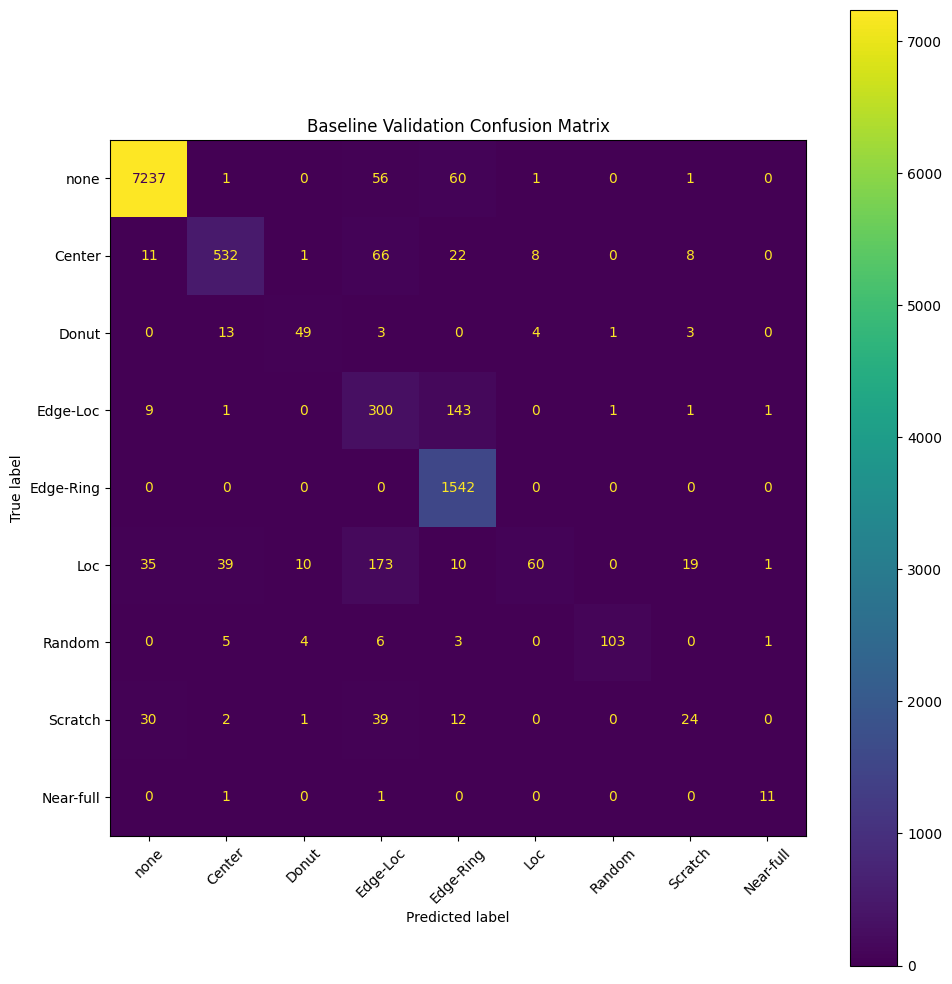

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    val_targets,
    val_preds,
    labels=list(range(len(classes)))
)

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title("Baseline Validation Confusion Matrix")
plt.tight_layout()
plt.show()

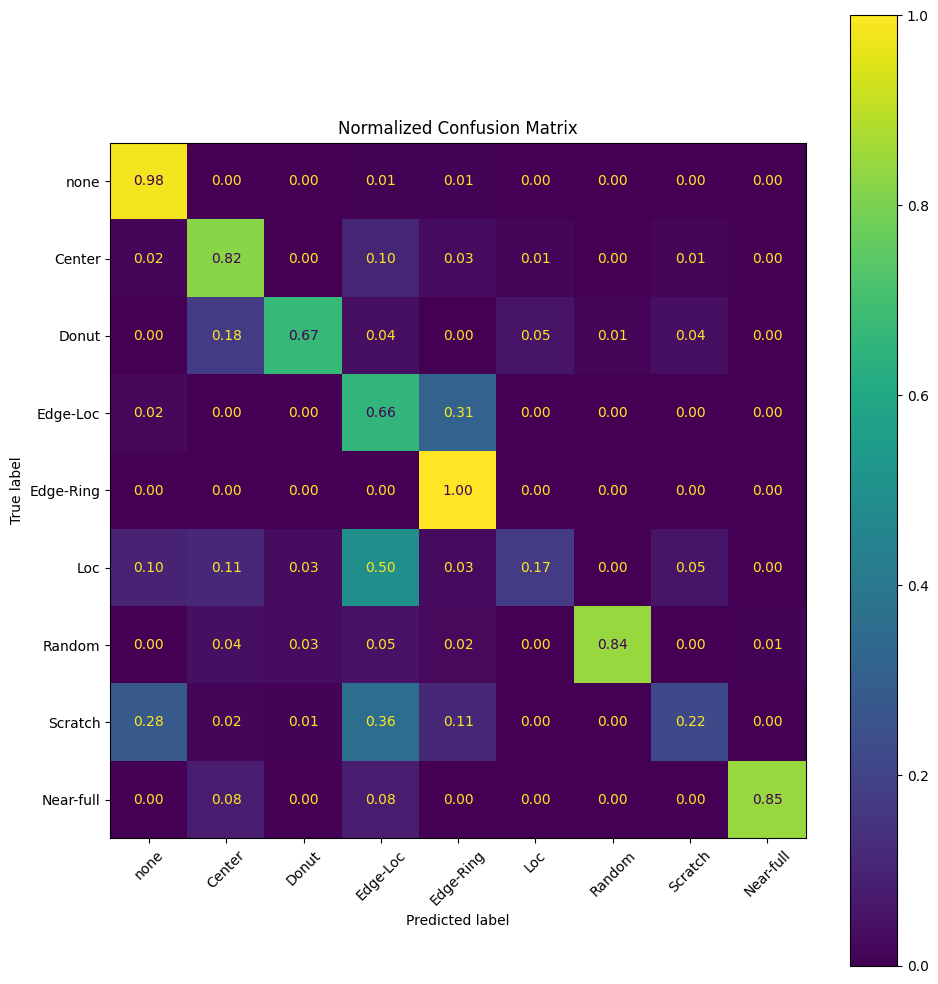

In [ ]:
import numpy as np

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=classes
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

Device: cuda

Label mapping:
{'none': 0, 'Center': 1, 'Donut': 2, 'Edge-Loc': 3, 'Edge-Ring': 4, 'Loc': 5, 'Random': 6, 'Scratch': 7, 'Near-full': 8}

Dataset size
Train: 43690
Validation: 10665

Model:
WaferCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, paddin

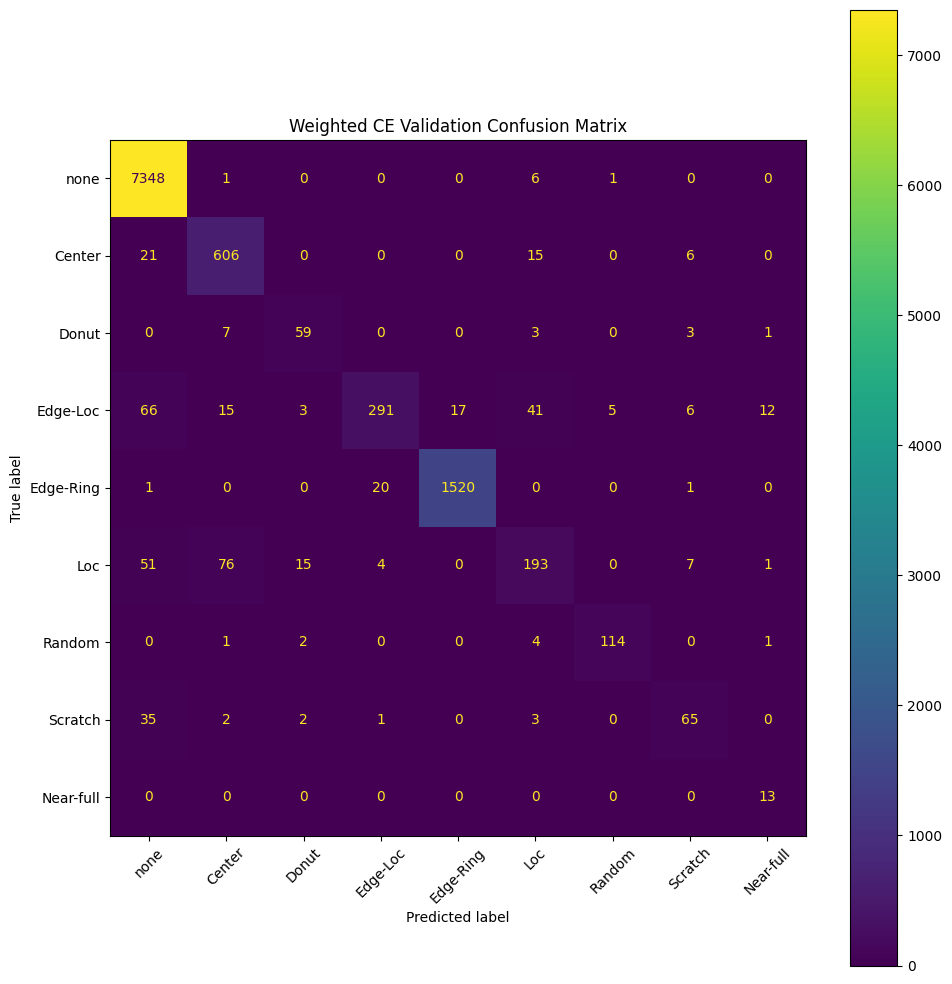

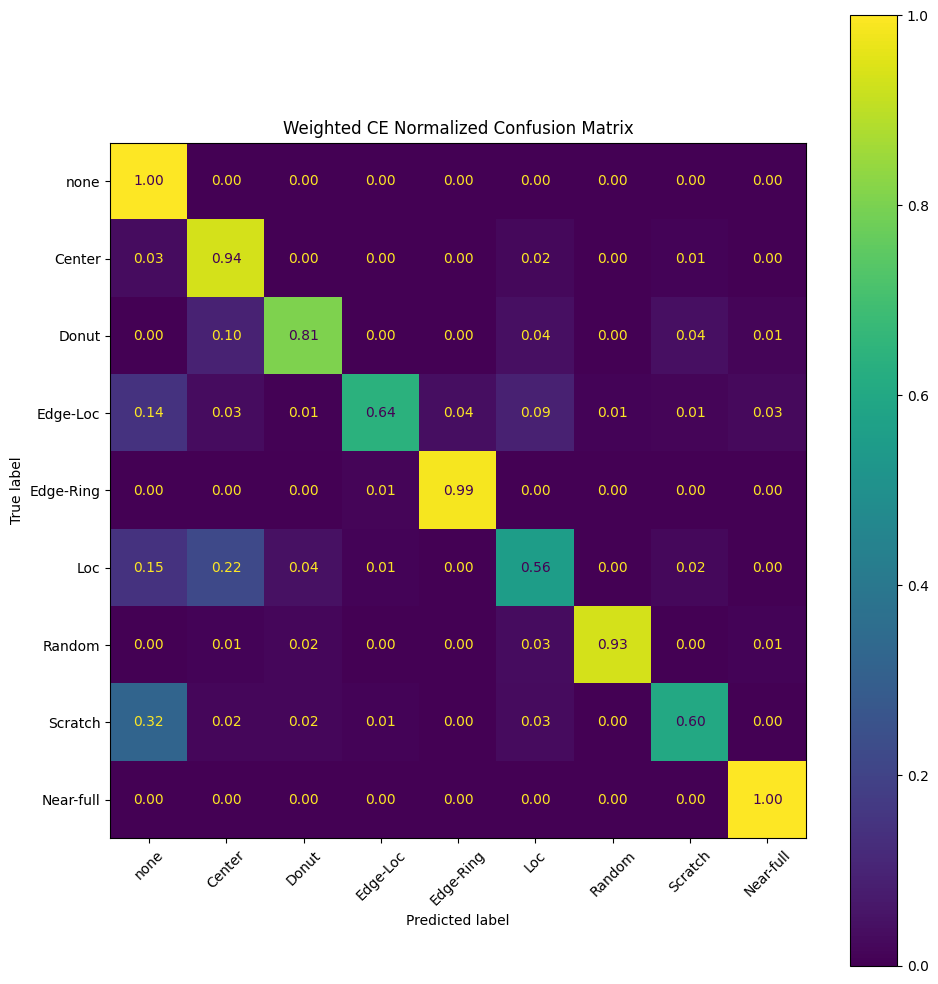


Training History
   epoch  train_loss  train_acc  train_f1  val_loss  val_acc  val_f1
0      1      0.7988     0.8665    0.5067    1.0617   0.6715  0.4751
1      2      0.4953     0.9225    0.6958    1.0707   0.6421  0.3763
2      3      0.3929     0.9384    0.7479    0.3892   0.8979  0.6993
3      4      0.3381     0.9463    0.7824    0.4136   0.9132  0.6183
4      5      0.3090     0.9528    0.7968    0.5179   0.9150  0.6485
5      6      0.2714     0.9573    0.8205    1.6437   0.4444  0.4117
6      7      0.2491     0.9625    0.8412    0.9900   0.6261  0.6268
7      8      0.2153     0.9666    0.8614    0.7111   0.9236  0.6059
8      9      0.1998     0.9682    0.8575    0.2264   0.9572  0.8066
9     10      0.1834     0.9727    0.8787    0.3441   0.9449  0.6984


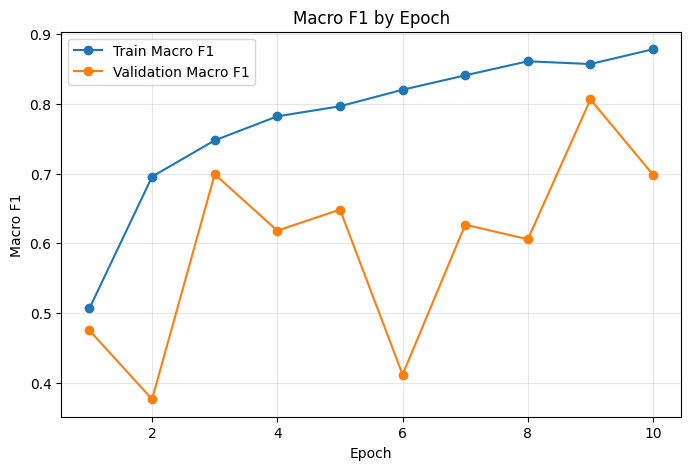

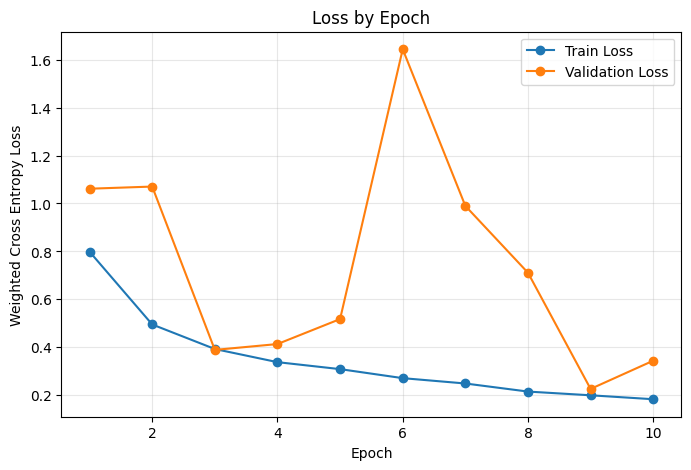

In [ ]:
# ============================================================
# WM-811K Weighted Cross Entropy Experiment
# - Same architecture as baseline
# - Same Train / Validation split
# - Only change: sqrt inverse-frequency class weights
# ============================================================

import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# 2. Device
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# 3. Class definition
# ============================================================

classes = [
    "none",
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-full",
]

label_to_idx = {
    label: idx
    for idx, label in enumerate(classes)
}

idx_to_label = {
    idx: label
    for label, idx in label_to_idx.items()
}

print("\nLabel mapping:")
print(label_to_idx)


# ============================================================
# 4. Dataset
# ============================================================

class WaferDataset(Dataset):

    def __init__(self, dataframe, size=64):
        self.df = dataframe.reset_index(drop=True)
        self.size = size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # Original wafer map: [H, W]
        wafer = torch.tensor(
            row["waferMap"],
            dtype=torch.float32
        )

        # [H, W] -> [1, 1, H, W]
        wafer = wafer.unsqueeze(0).unsqueeze(0)

        # Categorical map -> nearest-neighbor resize
        wafer = F.interpolate(
            wafer,
            size=(self.size, self.size),
            mode="nearest"
        )

        # [1, 1, 64, 64] -> [64, 64]
        wafer = wafer.squeeze(0).squeeze(0).long()

        # ----------------------------------------------------
        # 0 = outside wafer
        # 1 = normal die
        # 2 = failed die
        #
        # -> [3, 64, 64] one-hot representation
        # ----------------------------------------------------

        wafer = F.one_hot(
            wafer,
            num_classes=3
        )

        wafer = wafer.permute(
            2, 0, 1
        ).float()

        label = label_to_idx[
            row["failure_label"]
        ]

        return wafer, label


# ============================================================
# 5. Dataset / DataLoader
# ============================================================

train_dataset = WaferDataset(
    train_data,
    size=64
)

val_dataset = WaferDataset(
    val_data,
    size=64
)

BATCH_SIZE = 128

# Make DataLoader shuffling reproducible
generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    generator=generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nDataset size")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))


# ============================================================
# 6. CNN
#
# IMPORTANT:
# This is the SAME architecture as the baseline.
# Do not change it yet.
# ============================================================

class WaferCNN(nn.Module):

    def __init__(self, num_classes=9):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(

            nn.AdaptiveAvgPool2d(
                (1, 1)
            ),

            nn.Flatten(),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


model = WaferCNN(
    num_classes=len(classes)
).to(device)

print("\nModel:")
print(model)


# ============================================================
# 7. Calculate sqrt inverse-frequency class weights
# ============================================================

train_counts = (
    train_data["failure_label"]
    .value_counts()
    .reindex(classes)
)

counts = train_counts.values.astype(
    np.float32
)

# ------------------------------------------------------------
# sqrt inverse-frequency weighting
#
# w_c ∝ 1 / sqrt(n_c)
# ------------------------------------------------------------

weights = 1.0 / np.sqrt(counts)

# Normalize so mean weight = 1
weights = weights / weights.mean()

class_weights = torch.tensor(
    weights,
    dtype=torch.float32,
    device=device
)

print("\nClass weights")
print("-" * 50)

for cls, count, weight in zip(
    classes,
    counts,
    weights
):
    print(
        f"{cls:10s} "
        f"count={int(count):6d} "
        f"weight={weight:.4f}"
    )


# ============================================================
# 8. Loss / Optimizer
#
# Baseline:
# criterion = nn.CrossEntropyLoss()
#
# Experiment:
# weighted CrossEntropyLoss
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


# ============================================================
# 9. Training
# ============================================================

EPOCHS = 10

best_f1 = -1.0
best_epoch = -1
best_state = None

history = []

for epoch in range(1, EPOCHS + 1):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    train_loss = 0.0

    train_preds = []
    train_targets = []

    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        train_loss += (
            loss.item()
            * images.size(0)
        )

        preds = outputs.argmax(
            dim=1
        )

        train_preds.extend(
            preds.detach().cpu().numpy()
        )

        train_targets.extend(
            labels.detach().cpu().numpy()
        )

    train_loss /= len(
        train_loader.dataset
    )

    train_acc = accuracy_score(
        train_targets,
        train_preds
    )

    train_f1 = f1_score(
        train_targets,
        train_preds,
        average="macro",
        zero_division=0
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_loss = 0.0

    val_preds = []
    val_targets = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += (
                loss.item()
                * images.size(0)
            )

            preds = outputs.argmax(
                dim=1
            )

            val_preds.extend(
                preds.cpu().numpy()
            )

            val_targets.extend(
                labels.cpu().numpy()
            )

    val_loss /= len(
        val_loader.dataset
    )

    val_acc = accuracy_score(
        val_targets,
        val_preds
    )

    val_f1 = f1_score(
        val_targets,
        val_preds,
        average="macro",
        zero_division=0
    )


    # ========================================================
    # Save history
    # ========================================================

    history.append({
        "epoch": epoch,

        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,

        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1
    })


    # ========================================================
    # Save best model based on Macro F1
    # ========================================================

    if val_f1 > best_f1:

        best_f1 = val_f1
        best_epoch = epoch

        best_state = copy.deepcopy(
            model.state_dict()
        )


    print(
        f"[{epoch:02d}/{EPOCHS}] "
        f"train_loss={train_loss:.4f} "
        f"train_acc={train_acc:.4f} "
        f"train_f1={train_f1:.4f} | "
        f"val_loss={val_loss:.4f} "
        f"val_acc={val_acc:.4f} "
        f"val_f1={val_f1:.4f}"
    )


# ============================================================
# 10. Restore best checkpoint
# ============================================================

model.load_state_dict(
    best_state
)

print("\n" + "=" * 60)
print(
    f"Best Epoch: {best_epoch}"
)
print(
    f"Best Validation Macro F1: {best_f1:.4f}"
)
print("=" * 60)


# ============================================================
# 11. Final validation prediction
# ============================================================

model.eval()

val_preds = []
val_targets = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        preds = outputs.argmax(
            dim=1
        )

        val_preds.extend(
            preds.cpu().numpy()
        )

        val_targets.extend(
            labels.numpy()
        )


# ============================================================
# 12. Final metrics
# ============================================================

final_acc = accuracy_score(
    val_targets,
    val_preds
)

final_macro_f1 = f1_score(
    val_targets,
    val_preds,
    average="macro",
    zero_division=0
)

print("\nFinal Best Checkpoint")
print(
    f"Validation Accuracy : {final_acc:.4f}"
)
print(
    f"Validation Macro F1 : {final_macro_f1:.4f}"
)

print("\nClassification Report\n")

print(
    classification_report(
        val_targets,
        val_preds,
        labels=list(range(len(classes))),
        target_names=classes,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 13. Raw Confusion Matrix
# ============================================================

cm = confusion_matrix(
    val_targets,
    val_preds,
    labels=list(range(len(classes)))
)

fig, ax = plt.subplots(
    figsize=(10, 10)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title(
    "Weighted CE Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()


# ============================================================
# 14. Normalized Confusion Matrix
# ============================================================

cm_norm = (
    cm.astype(float)
    / cm.sum(
        axis=1,
        keepdims=True
    )
)

fig, ax = plt.subplots(
    figsize=(10, 10)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=classes
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format=".2f"
)

plt.title(
    "Weighted CE Normalized Confusion Matrix"
)

plt.tight_layout()
plt.show()


# ============================================================
# 15. Training History
# ============================================================

history_df = pd.DataFrame(
    history
)

print("\nTraining History")
print(
    history_df.round(4)
)


# ============================================================
# 16. Macro F1 curve
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_f1"],
    marker="o",
    label="Train Macro F1"
)

plt.plot(
    history_df["epoch"],
    history_df["val_f1"],
    marker="o",
    label="Validation Macro F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Macro F1 by Epoch")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 17. Loss curve
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Weighted Cross Entropy Loss")
plt.title("Loss by Epoch")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Device: cuda

Loading dataset...
Original shape: (811457, 6)
Columns:
['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']

Clean dataset size: 172950

Class distribution:
failureType_clean
none         147431
Center         4294
Donut           555
Edge-Loc       5189
Edge-Ring      9680
Loc            3593
Random          866
Scratch        1193
Near-full       149
Name: count, dtype: int64

Dataset size
Train: 162285
Validation: 10665

Train class distribution
none       138315
Center       4006
Donut         520
Edge-Loc     4892
Edge-Ring    9123
Loc          3362
Random        824
Scratch      1108
Near-full     135

Validation class distribution
none         9116
Center        288
Donut          35
Edge-Loc      297
Edge-Ring     557
Loc           231
Random         42
Scratch        85
Near-full      14

Class counts
--------------------------------------------------
none       count=138315
Center     count=  4006
Donut      count=   520
Edge-Loc   

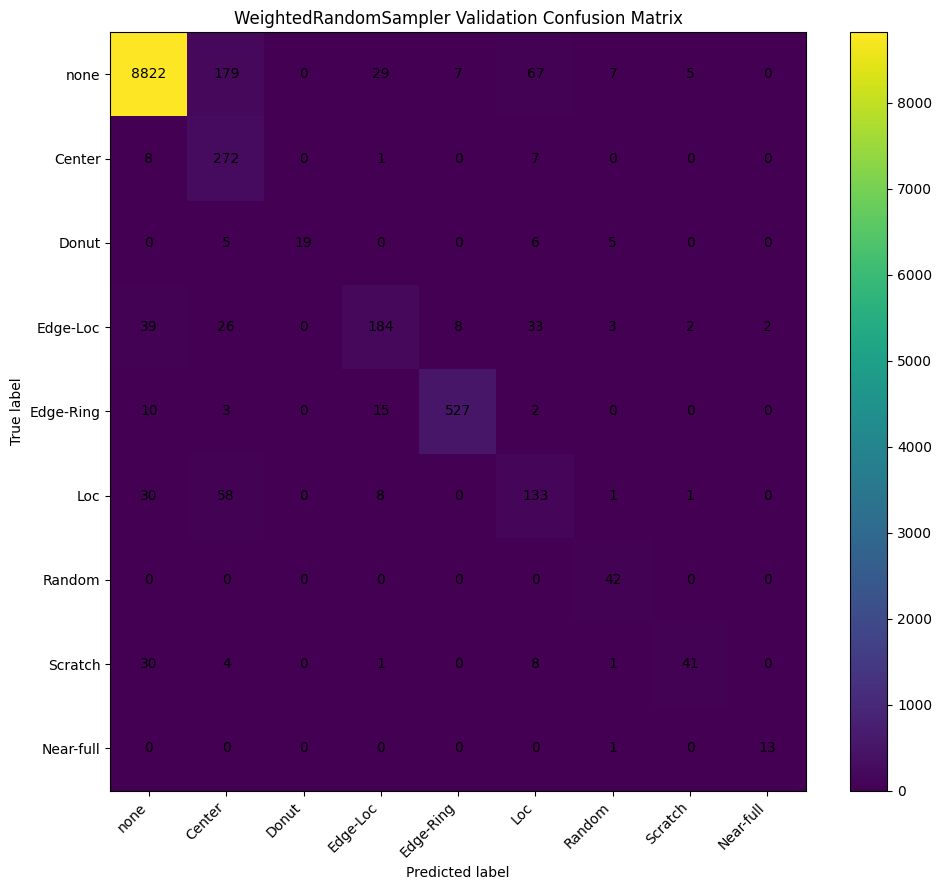

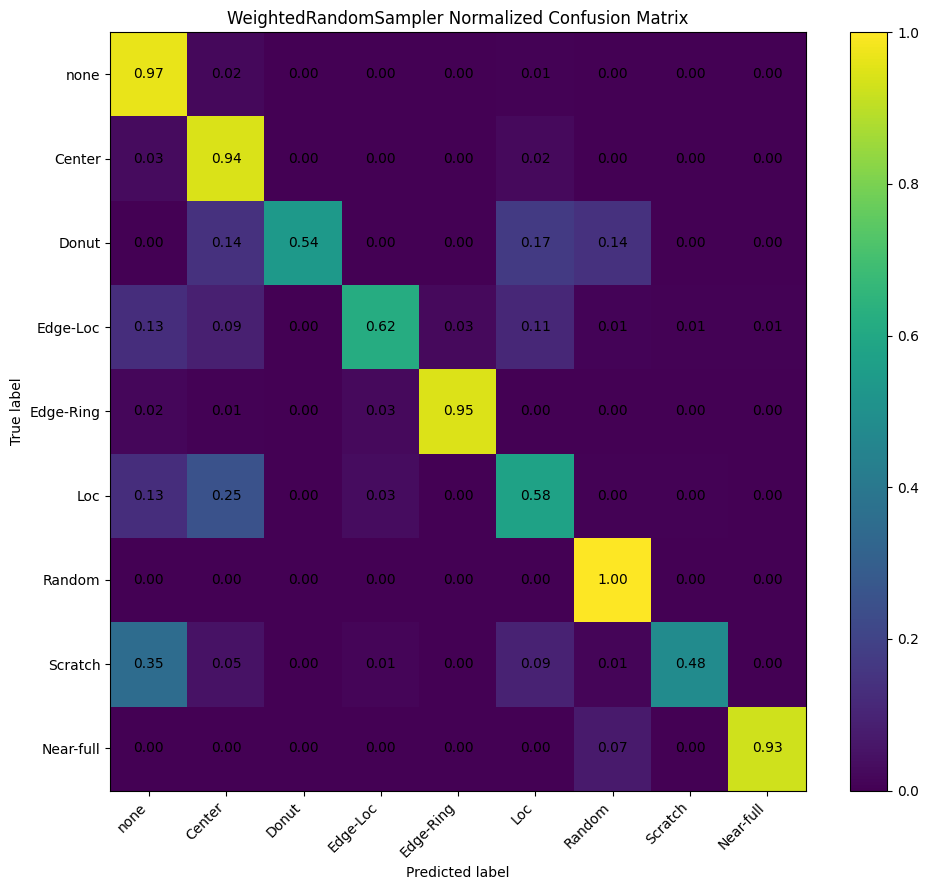

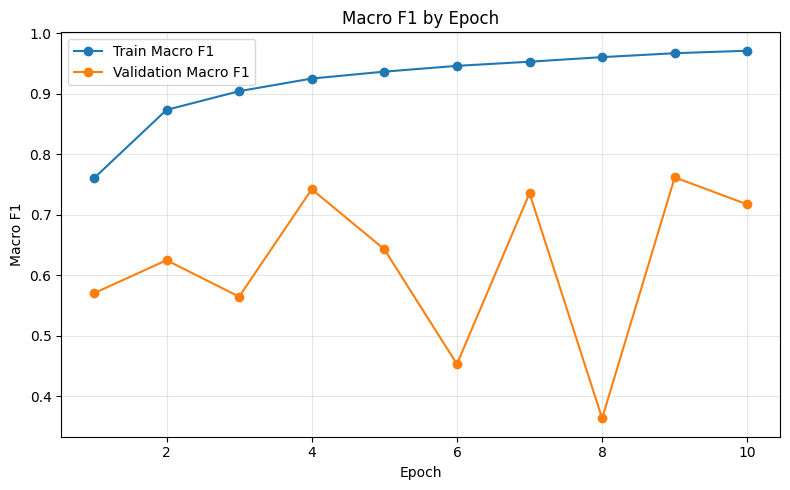

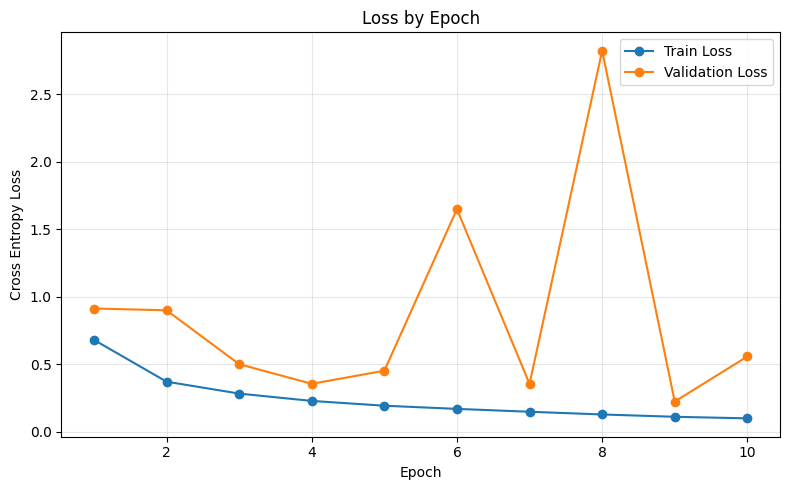


Per-class Results
       class  precision  recall      f1  support
0       none     0.9869  0.9677  0.9772     9116
1     Center     0.4973  0.9444  0.6515      288
2      Donut     1.0000  0.5429  0.7037       35
3   Edge-Loc     0.7731  0.6195  0.6879      297
4  Edge-Ring     0.9723  0.9461  0.9591      557
5        Loc     0.5195  0.5758  0.5462      231
6     Random     0.7000  1.0000  0.8235       42
7    Scratch     0.8367  0.4824  0.6119       85
8  Near-full     0.8667  0.9286  0.8966       14

Done.


In [ ]:
# ============================================================
# WM-811K Final Experiment
# WeightedRandomSampler + Standard CrossEntropyLoss
# ============================================================

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("ignore")


# ============================================================
# 1. Configuration
# ============================================================

PKL_PATH = "/content/drive/MyDrive/LSWMD.pkl/LSWMD.pkl"

SEED = 42

IMG_SIZE = 64
BATCH_SIZE = 128
EPOCHS = 10

LR = 1e-3

# 현재 실험 로그에서 사용한 validation 크기
VAL_SIZE = 10665

NUM_WORKERS = 2

BEST_MODEL_PATH = "best_wafer_sampler_model.pt"


LABELS = [
    "none",
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-full",
]

LABEL_TO_IDX = {
    label: idx
    for idx, label in enumerate(LABELS)
}

IDX_TO_LABEL = {
    idx: label
    for label, idx in LABEL_TO_IDX.items()
}


# ============================================================
# 2. Seed
# ============================================================

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)


# ============================================================
# 3. Device
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


# ============================================================
# 4. Helper
# WM-811K의 failureType / trainTestLabel은
# numpy array나 list 안에 문자열이 들어있는 경우가 있음
# ============================================================

def unwrap_value(x):
    """
    [['Center']], ['Center'], np.array(['Center']) 등
    다양한 형태를 일반 문자열로 변환
    """

    if isinstance(x, np.ndarray):

        if x.size == 0:
            return None

        x = x.reshape(-1)[0]

    if isinstance(x, (list, tuple)):

        if len(x) == 0:
            return None

        x = x[0]

    if x is None:
        return None

    return str(x)


# ============================================================
# 5. Load dataset
#
# 주의:
# pickle은 신뢰할 수 있는 출처의 파일만 로드해야 함.
# ============================================================

print("\nLoading dataset...")

df = pd.read_pickle(PKL_PATH)

print("Original shape:", df.shape)
print("Columns:")
print(df.columns.tolist())


# ============================================================
# 6. Clean labels
# ============================================================

df = df.copy()

df["failureType_clean"] = df["failureType"].apply(unwrap_value)

if "trainTestLabel" in df.columns:

    df["trainTestLabel_clean"] = (
        df["trainTestLabel"]
        .apply(unwrap_value)
    )


# ============================================================
# 기존 프로젝트에서 사용한 WM-811K Training subset 사용
# ============================================================

if "trainTestLabel_clean" in df.columns:

    unique_split_labels = df["trainTestLabel_clean"].dropna().unique()

    print("\ntrainTestLabel values:")
    print(unique_split_labels)

    training_mask = (
        df["trainTestLabel_clean"]
        .str.lower()
        .eq("training")
    )

    if training_mask.sum() > 0:

        df = df[training_mask].copy()

        print(
            "\nUsing trainTestLabel == Training subset:",
            len(df)
        )


# ============================================================
# 유효한 9개 클래스만 남김
# ============================================================

df = df[
    df["failureType_clean"].isin(LABELS)
].copy()

df["label"] = (
    df["failureType_clean"]
    .map(LABEL_TO_IDX)
    .astype(int)
)


# waferMap이 정상적인 2D 배열인지 확인
df = df[
    df["waferMap"].apply(
        lambda x:
        isinstance(x, np.ndarray)
        and x.ndim == 2
        and x.size > 0
    )
].copy()

df.reset_index(drop=True, inplace=True)


print("\nClean dataset size:", len(df))

print("\nClass distribution:")
print(
    df["failureType_clean"]
    .value_counts()
    .reindex(LABELS)
)


# ============================================================
# 7. Train / Validation split
#
# 현재 결과와 비교하기 위해 validation size = 10665 고정
# ============================================================

indices = np.arange(len(df))

train_idx, val_idx = train_test_split(
    indices,
    test_size=VAL_SIZE,
    random_state=SEED,
    shuffle=True,
)


train_df = (
    df.iloc[train_idx]
    .reset_index(drop=True)
)

val_df = (
    df.iloc[val_idx]
    .reset_index(drop=True)
)


print("\nDataset size")
print("Train:", len(train_df))
print("Validation:", len(val_df))


print("\nTrain class distribution")

for label in LABELS:

    count = (
        train_df["failureType_clean"]
        == label
    ).sum()

    print(
        f"{label:10s} "
        f"{count:6d}"
    )


print("\nValidation class distribution")

for label in LABELS:

    count = (
        val_df["failureType_clean"]
        == label
    ).sum()

    print(
        f"{label:10s} "
        f"{count:6d}"
    )


# ============================================================
# 8. Dataset
#
# waferMap 값:
# 0 = wafer outside / no die
# 1 = normal die
# 2 = defective die
#
# 단순 grayscale보다
# 0 / 1 / 2를 각각 one-hot channel로 분리
#
# 출력 shape:
# (3, 64, 64)
# ============================================================

class WaferDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe.reset_index(drop=True)


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        wafer = row["waferMap"]
        label = int(row["label"])


        # ----------------------------------------------------
        # One-hot channels
        # ----------------------------------------------------

        wafer_tensor = torch.stack(
            [
                torch.tensor(
                    wafer == 0,
                    dtype=torch.float32
                ),

                torch.tensor(
                    wafer == 1,
                    dtype=torch.float32
                ),

                torch.tensor(
                    wafer == 2,
                    dtype=torch.float32
                ),
            ],
            dim=0,
        )


        # (C, H, W)
        # ->
        # (1, C, H, W)
        wafer_tensor = wafer_tensor.unsqueeze(0)


        # categorical map이므로 nearest interpolation 사용
        wafer_tensor = F.interpolate(
            wafer_tensor,
            size=(IMG_SIZE, IMG_SIZE),
            mode="nearest",
        )


        wafer_tensor = wafer_tensor.squeeze(0)


        return wafer_tensor, label


train_dataset = WaferDataset(train_df)
val_dataset = WaferDataset(val_df)


# ============================================================
# 9. WeightedRandomSampler
# ============================================================

train_labels = train_df["label"].to_numpy()


class_counts = np.bincount(
    train_labels,
    minlength=len(LABELS)
)


print("\nClass counts")
print("-" * 50)

for idx, label in enumerate(LABELS):

    print(
        f"{label:10s} "
        f"count={class_counts[idx]:6d}"
    )


# ------------------------------------------------------------
# inverse frequency
#
# 희귀 클래스일수록 높은 sampling probability
# ------------------------------------------------------------

class_sample_weights = (
    1.0
    / class_counts.astype(np.float64)
)


sample_weights = np.array(
    [
        class_sample_weights[label]
        for label in train_labels
    ],
    dtype=np.float64,
)


sample_weights = torch.DoubleTensor(
    sample_weights
)


sampler_generator = torch.Generator()
sampler_generator.manual_seed(SEED)


train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
    generator=sampler_generator,
)


# ============================================================
# 10. DataLoader
#
# sampler와 shuffle=True를 동시에 사용하면 안 됨
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)


# ============================================================
# 11. Model
#
# 기존 Weighted CE 실험과 동일한 WaferCNN
# ============================================================

class WaferCNN(nn.Module):

    def __init__(self, num_classes=9):

        super().__init__()


        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.MaxPool2d(2),
        )


        self.classifier = nn.Sequential(

            nn.AdaptiveAvgPool2d((1, 1)),

            nn.Flatten(),

            nn.Linear(
                128,
                num_classes,
            ),
        )


    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


model = WaferCNN(
    num_classes=len(LABELS)
).to(device)


print("\nModel:")
print(model)


# ============================================================
# 12. Loss / Optimizer
#
# 핵심:
# Weighted CE 사용하지 않음
# ============================================================

criterion = nn.CrossEntropyLoss()


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
)


# ============================================================
# 13. Train one epoch
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
):

    model.train()


    running_loss = 0.0

    all_labels = []
    all_preds = []


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True,
        )

        labels = labels.to(
            device,
            non_blocking=True,
        )


        # ----------------------------------------------------
        # Gradient 초기화
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        logits = model(images)


        # ----------------------------------------------------
        # Standard CE
        # ----------------------------------------------------

        loss = criterion(
            logits,
            labels,
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        optimizer.step()


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        batch_size = images.size(0)

        running_loss += (
            loss.item()
            * batch_size
        )


        preds = logits.argmax(dim=1)


        all_labels.extend(
            labels
            .detach()
            .cpu()
            .numpy()
        )

        all_preds.extend(
            preds
            .detach()
            .cpu()
            .numpy()
        )


    epoch_loss = (
        running_loss
        / len(loader.dataset)
    )


    epoch_acc = accuracy_score(
        all_labels,
        all_preds,
    )


    epoch_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0,
    )


    return (
        epoch_loss,
        epoch_acc,
        epoch_f1,
    )


# ============================================================
# 14. Validation
# ============================================================

@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device,
):

    model.eval()


    running_loss = 0.0

    all_labels = []
    all_preds = []


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True,
        )

        labels = labels.to(
            device,
            non_blocking=True,
        )


        logits = model(images)


        loss = criterion(
            logits,
            labels,
        )


        batch_size = images.size(0)

        running_loss += (
            loss.item()
            * batch_size
        )


        preds = logits.argmax(dim=1)


        all_labels.extend(
            labels
            .cpu()
            .numpy()
        )

        all_preds.extend(
            preds
            .cpu()
            .numpy()
        )


    epoch_loss = (
        running_loss
        / len(loader.dataset)
    )


    epoch_acc = accuracy_score(
        all_labels,
        all_preds,
    )


    epoch_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0,
    )


    return (
        epoch_loss,
        epoch_acc,
        epoch_f1,
        np.array(all_labels),
        np.array(all_preds),
    )


# ============================================================
# 15. Training
#
# Best model 기준:
# Validation Macro F1
# ============================================================

history = []


best_val_f1 = -1.0
best_epoch = -1


print("\nTraining Start")
print("=" * 80)


for epoch in range(
    1,
    EPOCHS + 1
):


    (
        train_loss,
        train_acc,
        train_f1,
    ) = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device,
    )


    (
        val_loss,
        val_acc,
        val_f1,
        _,
        _,
    ) = evaluate(
        model,
        val_loader,
        criterion,
        device,
    )


    history.append(
        {
            "epoch": epoch,

            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_f1": train_f1,

            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
        }
    )


    print(
        f"[{epoch:02d}/{EPOCHS:02d}] "
        f"train_loss={train_loss:.4f} "
        f"train_acc={train_acc:.4f} "
        f"train_f1={train_f1:.4f} | "
        f"val_loss={val_loss:.4f} "
        f"val_acc={val_acc:.4f} "
        f"val_f1={val_f1:.4f}"
    )


    # --------------------------------------------------------
    # Macro F1 기준 best checkpoint
    # --------------------------------------------------------

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1
        best_epoch = epoch


        torch.save(
            {
                "epoch": epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "val_f1":
                    val_f1,

                "val_acc":
                    val_acc,

                "label_mapping":
                    LABEL_TO_IDX,
            },

            BEST_MODEL_PATH,
        )


print("\n" + "=" * 60)

print(
    f"Best Epoch: "
    f"{best_epoch}"
)

print(
    f"Best Validation Macro F1: "
    f"{best_val_f1:.4f}"
)

print("=" * 60)


# ============================================================
# 16. History DataFrame
# ============================================================

history_df = pd.DataFrame(history)


print("\nTraining History")
print(history_df.round(4))


history_df.to_csv(
    "sampler_training_history.csv",
    index=False,
)


# ============================================================
# 17. Load Best Checkpoint
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
)


model.load_state_dict(
    checkpoint["model_state_dict"]
)


# ============================================================
# 18. Final Evaluation
# ============================================================

(
    final_val_loss,
    final_val_acc,
    final_val_f1,
    y_true,
    y_pred,
) = evaluate(
    model,
    val_loader,
    criterion,
    device,
)


print("\nFinal Best Checkpoint")

print(
    f"Validation Accuracy : "
    f"{final_val_acc:.4f}"
)

print(
    f"Validation Macro F1 : "
    f"{final_val_f1:.4f}"
)


# ============================================================
# 19. Classification Report
# ============================================================

print("\nClassification Report\n")


print(
    classification_report(
        y_true,
        y_pred,

        labels=range(len(LABELS)),

        target_names=LABELS,

        digits=4,

        zero_division=0,
    )
)


# ============================================================
# 20. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=range(len(LABELS)),
)


# ------------------------------------------------------------
# Normalized confusion matrix
# ------------------------------------------------------------

cm_normalized = (
    cm.astype(np.float64)
    / cm.sum(
        axis=1,
        keepdims=True,
    )
)


# ============================================================
# 21. Plot function
# ============================================================

def plot_confusion_matrix(
    matrix,
    labels,
    title,
    fmt,
    filename,
):

    fig, ax = plt.subplots(
        figsize=(10, 9)
    )


    im = ax.imshow(
        matrix,
        aspect="auto",
    )


    fig.colorbar(
        im,
        ax=ax,
    )


    ax.set_title(title)

    ax.set_xlabel(
        "Predicted label"
    )

    ax.set_ylabel(
        "True label"
    )


    ax.set_xticks(
        range(len(labels))
    )

    ax.set_yticks(
        range(len(labels))
    )


    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right",
    )

    ax.set_yticklabels(labels)


    threshold = (
        matrix.max()
        / 2
        if matrix.size
        else 0
    )


    for i in range(
        matrix.shape[0]
    ):

        for j in range(
            matrix.shape[1]
        ):

            value = matrix[i, j]

            if fmt == ".2f":

                text = f"{value:.2f}"

            else:

                text = f"{int(value)}"


            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
            )


    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()


# ============================================================
# 22. Raw Confusion Matrix
# ============================================================

plot_confusion_matrix(
    cm,
    LABELS,

    title=(
        "WeightedRandomSampler "
        "Validation Confusion Matrix"
    ),

    fmt="d",

    filename=(
        "sampler_confusion_matrix.png"
    ),
)


# ============================================================
# 23. Normalized Confusion Matrix
# ============================================================

plot_confusion_matrix(
    cm_normalized,
    LABELS,

    title=(
        "WeightedRandomSampler "
        "Normalized Confusion Matrix"
    ),

    fmt=".2f",

    filename=(
        "sampler_confusion_matrix_normalized.png"
    ),
)


# ============================================================
# 24. Macro F1 history
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_f1"],
    marker="o",
    label="Train Macro F1",
)

plt.plot(
    history_df["epoch"],
    history_df["val_f1"],
    marker="o",
    label="Validation Macro F1",
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")

plt.title(
    "Macro F1 by Epoch"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "sampler_macro_f1_history.png",
    dpi=200,
)

plt.show()


# ============================================================
# 25. Loss history
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train Loss",
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")

plt.title(
    "Loss by Epoch"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "sampler_loss_history.png",
    dpi=200,
)

plt.show()


# ============================================================
# 26. Per-class result table
# ============================================================

report_dict = classification_report(
    y_true,
    y_pred,

    labels=range(len(LABELS)),

    target_names=LABELS,

    output_dict=True,

    zero_division=0,
)


class_result = []


for label in LABELS:

    result = report_dict[label]

    class_result.append(
        {
            "class": label,

            "precision":
                result["precision"],

            "recall":
                result["recall"],

            "f1":
                result["f1-score"],

            "support":
                int(result["support"]),
        }
    )


class_result_df = pd.DataFrame(
    class_result
)


print("\nPer-class Results")

print(
    class_result_df.round(4)
)


class_result_df.to_csv(
    "sampler_class_results.csv",
    index=False,
)


print("\nDone.")

Device: cuda

Label mapping:
{'none': 0, 'Center': 1, 'Donut': 2, 'Edge-Loc': 3, 'Edge-Ring': 4, 'Loc': 5, 'Random': 6, 'Scratch': 7, 'Near-full': 8}

Dataset size
Train: 162285
Validation: 10665

Train class distribution
failureType_clean
none         138315
Center         4006
Donut           520
Edge-Loc       4892
Edge-Ring      9123
Loc            3362
Random          824
Scratch        1108
Near-full       135
Name: count, dtype: int64

Class weights
------------------------------------------------------------
none       count=138315 weight=0.0948
Center     count=  4006 weight=0.5570
Donut      count=   520 weight=1.5459
Edge-Loc   count=  4892 weight=0.5040
Edge-Ring  count=  9123 weight=0.3691
Loc        count=  3362 weight=0.6080
Random     count=   824 weight=1.2281
Scratch    count=  1108 weight=1.0591
Near-full  count=   135 weight=3.0341

Model:
WaferCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm

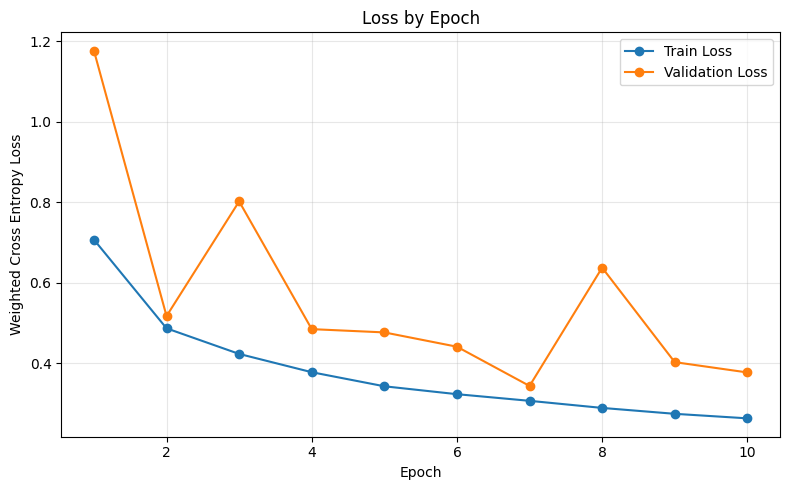

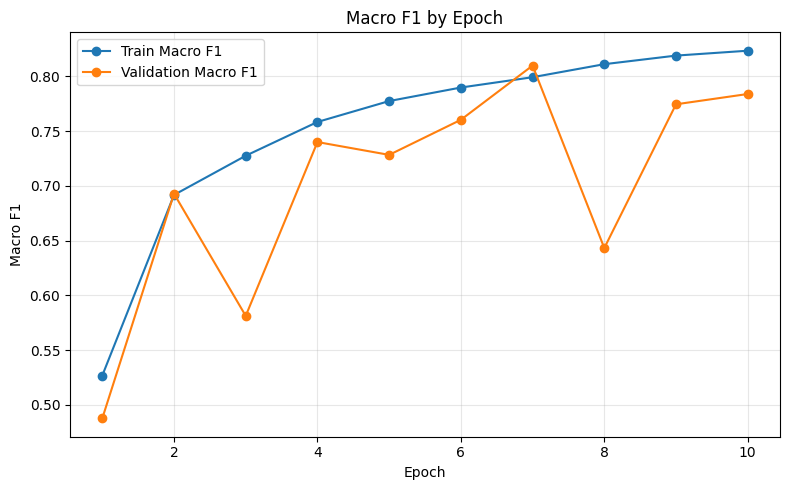

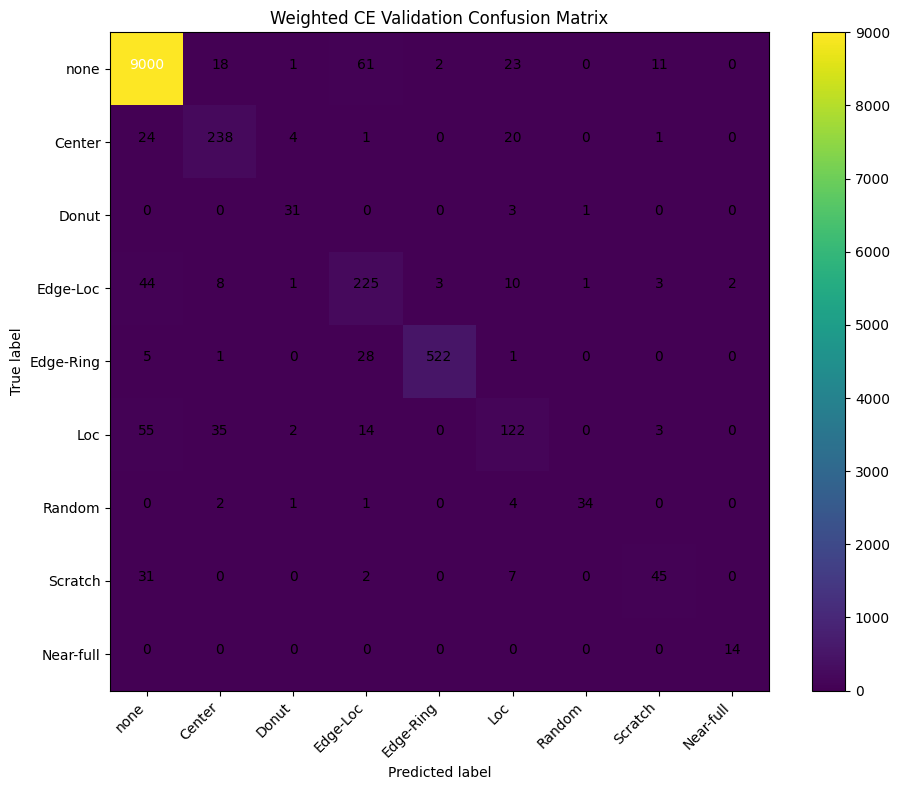

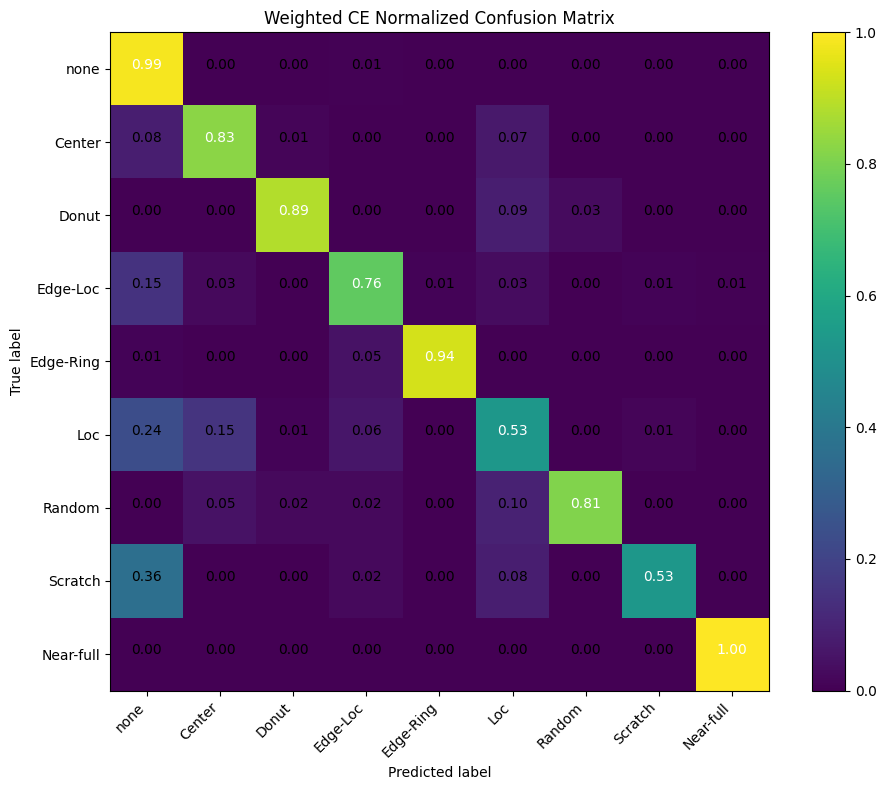


FINAL COMPARISON
WeightedRandomSampler | Acc=0.9426 | Macro F1=0.7620
Weighted CE            | Acc=0.9593 | Macro F1=0.8100
------------------------------------------------------------
Macro F1 difference (Weighted CE - Sampler): +0.0480
Accuracy difference (Weighted CE - Sampler): +0.0167

Done.


In [ ]:
# ============================================================
# FINAL EXPERIMENT
# Full Dataset + Weighted Cross Entropy
#
# 비교 대상:
#   1. WeightedRandomSampler
#   2. Weighted Cross Entropy  <-- 이번 실험
#
# 중요:
# - train_dataset / val_dataset 그대로 사용
# - train_df / val_df 그대로 사용
# - WaferCNN 그대로 사용
# - Sampler 사용 X
# - shuffle=True
# - inverse sqrt class weight 사용
# ============================================================

import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# ------------------------------------------------------------
# 1. Seed
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ------------------------------------------------------------
# 2. Device
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


# ------------------------------------------------------------
# 3. Class definition
# ------------------------------------------------------------

CLASS_NAMES = [
    "none",
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-full",
]

label_to_idx = {
    name: idx
    for idx, name in enumerate(CLASS_NAMES)
}

print("\nLabel mapping:")
print(label_to_idx)


# ------------------------------------------------------------
# 4. Dataset size check
# ------------------------------------------------------------

print("\nDataset size")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

print("\nTrain class distribution")

train_counts = (
    train_df["failureType_clean"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .fillna(0)
    .astype(int)
)

print(train_counts)


# ------------------------------------------------------------
# 5. DataLoader
#
# IMPORTANT:
# WeightedRandomSampler 사용하지 않는다.
# 실제 데이터 분포는 그대로 유지한다.
# ------------------------------------------------------------

# 직전 실험에서 이미 BATCH_SIZE를 정의했다면 그대로 사용
try:
    BATCH_SIZE
except NameError:
    BATCH_SIZE = 128

try:
    NUM_WORKERS
except NameError:
    NUM_WORKERS = 0


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,              # 핵심
    sampler=None,              # WeightedRandomSampler 제거
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)


# ------------------------------------------------------------
# 6. Class Weight
#
# inverse sqrt weighting
#
# weight_c ∝ 1 / sqrt(N_c)
#
# 단순 inverse frequency보다 과도한 minority 보정을 줄이기 위해
# sqrt를 사용한다.
# ------------------------------------------------------------

counts = train_counts.values.astype(np.float32)

raw_weights = 1.0 / np.sqrt(counts)

# 평균 weight가 1이 되도록 normalization
class_weights_np = raw_weights / raw_weights.mean()

class_weights = torch.tensor(
    class_weights_np,
    dtype=torch.float32,
    device=device,
)


print("\nClass weights")
print("-" * 60)

for name, count, weight in zip(
    CLASS_NAMES,
    counts.astype(int),
    class_weights_np,
):
    print(
        f"{name:10s} "
        f"count={count:6d} "
        f"weight={weight:.4f}"
    )


# ------------------------------------------------------------
# 7. New Model
#
# 반드시 새 모델로 시작
# Sampler 실험에서 학습된 weight 사용 X
# ------------------------------------------------------------

model = WaferCNN().to(device)

print("\nModel:")
print(model)


# ------------------------------------------------------------
# 8. Weighted Cross Entropy
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ------------------------------------------------------------
# 9. Optimizer
#
# 가능하면 방금 Sampler 실험에서 사용한 optimizer 설정을
# 그대로 복제한다.
# ------------------------------------------------------------

# 기존 optimizer가 notebook에 남아 있으면
# optimizer 종류와 설정을 그대로 재사용
if "optimizer" in globals():

    old_optimizer = optimizer

    optimizer_class = type(old_optimizer)
    optimizer_kwargs = dict(old_optimizer.defaults)

    optimizer = optimizer_class(
        model.parameters(),
        **optimizer_kwargs,
    )

    print(
        "\nOptimizer copied from previous experiment:"
    )
    print(optimizer_class.__name__)
    print(optimizer_kwargs)

else:

    # 기존 optimizer 변수가 없을 경우 기본값
    LR = 1e-3

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LR,
    )

    print("\nOptimizer: Adam")
    print("LR:", LR)


# ------------------------------------------------------------
# 10. Epoch
# ------------------------------------------------------------

EPOCHS = 10


# ------------------------------------------------------------
# 11. Train function
# ------------------------------------------------------------

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
):

    model.train()

    total_loss = 0.0

    all_targets = []
    all_preds = []

    for images, targets in loader:

        images = images.to(
            device,
            non_blocking=True,
        )

        targets = targets.to(
            device,
            non_blocking=True,
        )

        # ----------------------------
        # forward
        # ----------------------------

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(
            logits,
            targets,
        )

        # ----------------------------
        # backward
        # ----------------------------

        loss.backward()

        optimizer.step()

        # ----------------------------
        # statistics
        # ----------------------------

        total_loss += (
            loss.item()
            * images.size(0)
        )

        preds = logits.argmax(dim=1)

        all_targets.extend(
            targets.detach().cpu().numpy()
        )

        all_preds.extend(
            preds.detach().cpu().numpy()
        )


    epoch_loss = (
        total_loss
        / len(loader.dataset)
    )

    epoch_acc = accuracy_score(
        all_targets,
        all_preds,
    )

    epoch_f1 = f1_score(
        all_targets,
        all_preds,
        average="macro",
        zero_division=0,
    )

    return (
        epoch_loss,
        epoch_acc,
        epoch_f1,
    )


# ------------------------------------------------------------
# 12. Validation function
# ------------------------------------------------------------

@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device,
):

    model.eval()

    total_loss = 0.0

    all_targets = []
    all_preds = []

    for images, targets in loader:

        images = images.to(
            device,
            non_blocking=True,
        )

        targets = targets.to(
            device,
            non_blocking=True,
        )

        logits = model(images)

        loss = criterion(
            logits,
            targets,
        )

        total_loss += (
            loss.item()
            * images.size(0)
        )

        preds = logits.argmax(dim=1)

        all_targets.extend(
            targets.cpu().numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )


    epoch_loss = (
        total_loss
        / len(loader.dataset)
    )

    epoch_acc = accuracy_score(
        all_targets,
        all_preds,
    )

    epoch_f1 = f1_score(
        all_targets,
        all_preds,
        average="macro",
        zero_division=0,
    )

    return (
        epoch_loss,
        epoch_acc,
        epoch_f1,
        np.array(all_targets),
        np.array(all_preds),
    )


# ------------------------------------------------------------
# 13. Training
# ------------------------------------------------------------

history = []

best_val_f1 = -1.0
best_epoch = -1
best_state = None


print("\nTraining Start")
print("=" * 80)


for epoch in range(
    1,
    EPOCHS + 1,
):

    # ----------------------------
    # Train
    # ----------------------------

    train_loss, train_acc, train_f1 = (
        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
        )
    )

    # ----------------------------
    # Validation
    # ----------------------------

    (
        val_loss,
        val_acc,
        val_f1,
        val_targets,
        val_preds,
    ) = evaluate(
        model,
        val_loader,
        criterion,
        device,
    )


    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_f1": train_f1,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
        }
    )


    print(
        f"[{epoch:02d}/{EPOCHS:02d}] "
        f"train_loss={train_loss:.4f} "
        f"train_acc={train_acc:.4f} "
        f"train_f1={train_f1:.4f} | "
        f"val_loss={val_loss:.4f} "
        f"val_acc={val_acc:.4f} "
        f"val_f1={val_f1:.4f}"
    )


    # ----------------------------
    # Best checkpoint
    #
    # Accuracy가 아니라
    # Macro F1 기준으로 저장
    # ----------------------------

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1
        best_epoch = epoch

        best_state = copy.deepcopy(
            model.state_dict()
        )


# ------------------------------------------------------------
# 14. Best checkpoint
# ------------------------------------------------------------

print("\n" + "=" * 60)
print(
    f"Best Epoch: {best_epoch}"
)
print(
    f"Best Validation Macro F1: "
    f"{best_val_f1:.4f}"
)
print("=" * 60)


model.load_state_dict(
    best_state
)


torch.save(
    {
        "epoch": best_epoch,
        "model_state_dict": best_state,
        "class_names": CLASS_NAMES,
        "class_weights": class_weights_np,
        "best_val_f1": best_val_f1,
    },
    "weighted_ce_final_best.pt",
)


# ------------------------------------------------------------
# 15. Final validation
# ------------------------------------------------------------

(
    final_val_loss,
    final_val_acc,
    final_val_f1,
    y_true,
    y_pred,
) = evaluate(
    model,
    val_loader,
    criterion,
    device,
)


print("\nFinal Best Checkpoint")

print(
    f"Validation Accuracy : "
    f"{final_val_acc:.4f}"
)

print(
    f"Validation Macro F1 : "
    f"{final_val_f1:.4f}"
)


# ------------------------------------------------------------
# 16. Classification Report
# ------------------------------------------------------------

print("\nClassification Report\n")

report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
)

print(report)


# ------------------------------------------------------------
# 17. Per-class DataFrame
# ------------------------------------------------------------

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

per_class_results = []

for name in CLASS_NAMES:

    row = report_dict[name]

    per_class_results.append(
        {
            "class": name,
            "precision": row["precision"],
            "recall": row["recall"],
            "f1": row["f1-score"],
            "support": int(row["support"]),
        }
    )


per_class_df = pd.DataFrame(
    per_class_results
)

print("\nPer-class Results")
print(
    per_class_df.round(4)
)


# ------------------------------------------------------------
# 18. Training history
# ------------------------------------------------------------

history_df = pd.DataFrame(
    history
)

print("\nTraining History")
print(
    history_df.round(4)
)


history_df.to_csv(
    "weighted_ce_final_history.csv",
    index=False,
)

per_class_df.to_csv(
    "weighted_ce_final_per_class.csv",
    index=False,
)


# ------------------------------------------------------------
# 19. Loss curve
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train Loss",
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Weighted Cross Entropy Loss")
plt.title("Loss by Epoch")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 20. Macro F1 curve
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_f1"],
    marker="o",
    label="Train Macro F1",
)

plt.plot(
    history_df["epoch"],
    history_df["val_f1"],
    marker="o",
    label="Validation Macro F1",
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Macro F1 by Epoch")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 21. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
)


plt.figure(
    figsize=(10, 8)
)

plt.imshow(
    cm,
    interpolation="nearest",
)

plt.title(
    "Weighted CE Validation Confusion Matrix"
)

plt.colorbar()

ticks = np.arange(
    len(CLASS_NAMES)
)

plt.xticks(
    ticks,
    CLASS_NAMES,
    rotation=45,
    ha="right",
)

plt.yticks(
    ticks,
    CLASS_NAMES,
)


threshold = cm.max() / 2.0

for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            horizontalalignment="center",
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            ),
        )


plt.ylabel("True label")
plt.xlabel("Predicted label")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 22. Normalized Confusion Matrix
# ------------------------------------------------------------

row_sum = cm.sum(
    axis=1,
    keepdims=True,
)

cm_normalized = np.divide(
    cm,
    row_sum,
    out=np.zeros_like(
        cm,
        dtype=float,
    ),
    where=row_sum != 0,
)


plt.figure(
    figsize=(10, 8)
)

plt.imshow(
    cm_normalized,
    interpolation="nearest",
    vmin=0,
    vmax=1,
)

plt.title(
    "Weighted CE Normalized Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    ticks,
    CLASS_NAMES,
    rotation=45,
    ha="right",
)

plt.yticks(
    ticks,
    CLASS_NAMES,
)


for i in range(
    cm_normalized.shape[0]
):

    for j in range(
        cm_normalized.shape[1]
    ):

        value = cm_normalized[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            horizontalalignment="center",
            color=(
                "white"
                if value > 0.5
                else "black"
            ),
        )


plt.ylabel("True label")
plt.xlabel("Predicted label")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 23. Comparison with WeightedRandomSampler
# ------------------------------------------------------------

SAMPLER_ACC = 0.9426
SAMPLER_MACRO_F1 = 0.7620


print("\n" + "=" * 60)
print("FINAL COMPARISON")
print("=" * 60)

print(
    f"WeightedRandomSampler "
    f"| Acc={SAMPLER_ACC:.4f} "
    f"| Macro F1={SAMPLER_MACRO_F1:.4f}"
)

print(
    f"Weighted CE            "
    f"| Acc={final_val_acc:.4f} "
    f"| Macro F1={final_val_f1:.4f}"
)

print("-" * 60)

print(
    "Macro F1 difference "
    "(Weighted CE - Sampler): "
    f"{final_val_f1 - SAMPLER_MACRO_F1:+.4f}"
)

print(
    "Accuracy difference "
    "(Weighted CE - Sampler): "
    f"{final_val_acc - SAMPLER_ACC:+.4f}"
)

print("\nDone.")

Python / PyTorch environment
Torch version: 2.13.0+cu130
CUDA available: True
torch._utils loaded: True
WM-811K FINAL EXPERIMENT
Device: cuda

Label mapping:
{'none': 0, 'Center': 1, 'Donut': 2, 'Edge-Loc': 3, 'Edge-Ring': 4, 'Loc': 5, 'Random': 6, 'Scratch': 7, 'Near-full': 8}

Loading dataset...
Original shape: (811457, 6)
Columns:
['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']

Clean dataset size: 172950

Class distribution:
failureType_clean
none         147431
Center         4294
Donut           555
Edge-Loc       5189
Edge-Ring      9680
Loc            3593
Random          866
Scratch        1193
Near-full       149
Name: count, dtype: int64

FINAL DATA SPLIT
Train      : 138360
Validation : 17295
Test       : 17295

Train class distribution
failureType_clean
none         117945
Center         3435
Donut           444
Edge-Loc       4151
Edge-Ring      7744
Loc            2875
Random          693
Scratch         954
Near-full       119
Name: cou

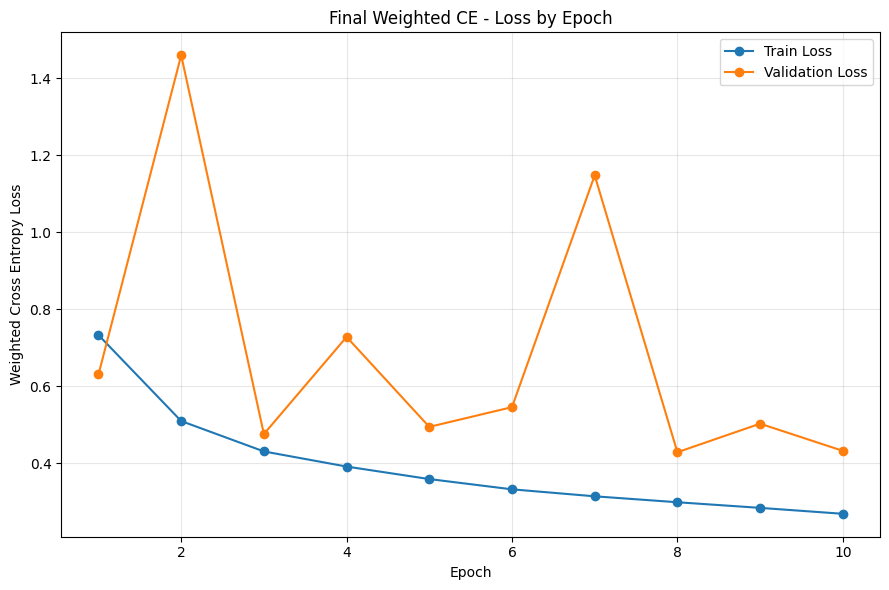

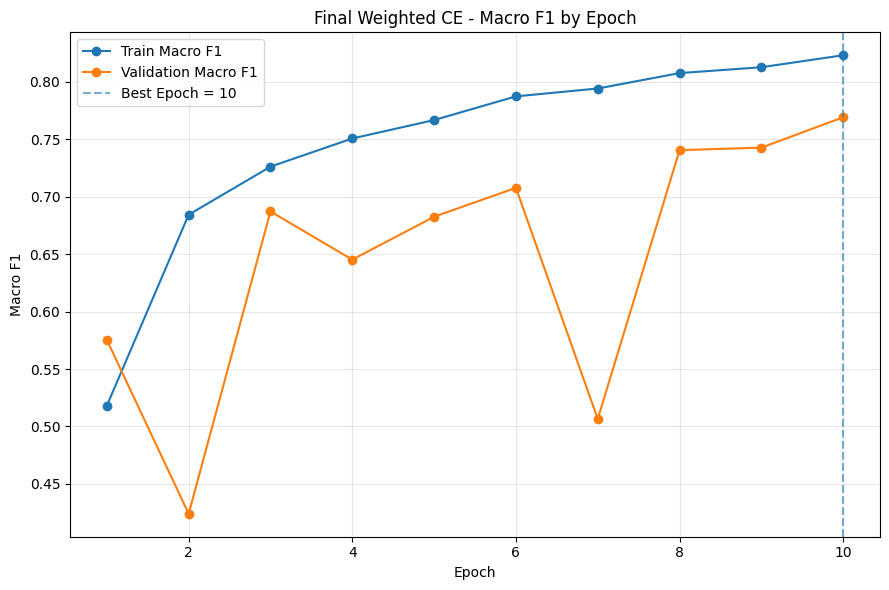

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray._reconstruct was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray._reconstruct])` or the `torch.serialization.safe_globals([numpy._core.multiarray._reconstruct])` context manager to allowlist this global if you trust this class/function.

Check the documentation of to

In [ ]:
# ============================================================
# WM-811K FINAL EXPERIMENT
# Weighted Cross Entropy + Held-out Test Set
#
# Train 80% / Validation 10% / Test 10%
# Model selection: Validation Macro F1
# Final evaluation: Test set ONCE
# ============================================================

# ============================================================
# Imports
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch._utils
import torch.optim
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Python / PyTorch environment")
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("torch._utils loaded:", hasattr(torch, "_utils"))

import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)


# ============================================================
# 1. Configuration
# ============================================================

PKL_PATH = "/content/drive/MyDrive/LSWMD.pkl/LSWMD.pkl"

SEED = 42

IMG_SIZE = 64
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 1e-3

# Windows/Jupyter에서도 안전하게 0으로 설정
# Colab이라면 2~4로 높여도 됨
NUM_WORKERS = 0

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

CLASS_NAMES = [
    "none",
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-full",
]

LABEL_TO_IDX = {
    name: idx for idx, name in enumerate(CLASS_NAMES)
}

NUM_CLASSES = len(CLASS_NAMES)


# ============================================================
# 2. Reproducibility
# ============================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)


print("=" * 70)
print("WM-811K FINAL EXPERIMENT")
print("=" * 70)
print("Device:", DEVICE)
print()
print("Label mapping:")
print(LABEL_TO_IDX)


# ============================================================
# 3. Load Dataset
# ============================================================

print("\nLoading dataset...")

df = pd.read_pickle(PKL_PATH)

print("Original shape:", df.shape)
print("Columns:")
print(df.columns.tolist())


# ============================================================
# 4. Clean failureType
# ============================================================

def extract_label(value):
    """
    WM-811K의 failureType은
    문자열이 아니라 numpy array / list 형태로 저장된 경우가 많다.

    예:
        array([['none']], dtype='<U4')
        array([], shape=(0, 0), dtype=float64)

    이를 일반 문자열로 변환한다.
    """

    if isinstance(value, str):
        return value.strip()

    if isinstance(value, (list, tuple, np.ndarray)):
        arr = np.asarray(value)

        if arr.size == 0:
            return None

        return str(arr.flatten()[0]).strip()

    return None


df["failureType_clean"] = df["failureType"].apply(extract_label)

# 우리가 사용할 9개 클래스만 유지
df = df[
    df["failureType_clean"].isin(CLASS_NAMES)
].copy()

# 인덱스를 따로 보존
df["original_index"] = df.index

df = df.reset_index(drop=True)

print("\nClean dataset size:", len(df))

print("\nClass distribution:")
print(
    df["failureType_clean"]
    .value_counts()
    .reindex(CLASS_NAMES)
)


# ============================================================
# 5. Train / Validation / Test Split
# ============================================================

# ------------------------------------------------------------
# 1차 분할
# Train 80%
# Temp 20%
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["failureType_clean"],
)

# ------------------------------------------------------------
# 2차 분할
# Temp -> Validation 10% + Test 10%
# ------------------------------------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["failureType_clean"],
)


# 인덱스 초기화
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


print("\n" + "=" * 70)
print("FINAL DATA SPLIT")
print("=" * 70)

print(f"Train      : {len(train_df)}")
print(f"Validation : {len(val_df)}")
print(f"Test       : {len(test_df)}")


def print_distribution(name, dataframe):

    print(f"\n{name} class distribution")

    counts = (
        dataframe["failureType_clean"]
        .value_counts()
        .reindex(CLASS_NAMES)
        .fillna(0)
        .astype(int)
    )

    print(counts)


print_distribution("Train", train_df)
print_distribution("Validation", val_df)
print_distribution("Test", test_df)


# ------------------------------------------------------------
# split 정보 저장
# 나중에 같은 데이터로 재현 가능
# ------------------------------------------------------------

split_info = pd.concat(
    [
        pd.DataFrame({
            "original_index": train_df["original_index"],
            "split": "train",
        }),
        pd.DataFrame({
            "original_index": val_df["original_index"],
            "split": "validation",
        }),
        pd.DataFrame({
            "original_index": test_df["original_index"],
            "split": "test",
        }),
    ],
    ignore_index=True,
)

split_info.to_csv(
    "final_data_split.csv",
    index=False,
)

print("\nSaved: final_data_split.csv")


# ============================================================
# 6. Dataset Class
# ============================================================

class WaferDataset(Dataset):

    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        wafer = np.asarray(
            row["waferMap"],
            dtype=np.int64,
        )

        # ----------------------------------------------------
        # Original wafer values
        #
        # 0 = outside wafer / no die
        # 1 = normal die
        # 2 = defective die
        # ----------------------------------------------------

        wafer_tensor = torch.from_numpy(
            wafer
        ).float()

        # [H, W]
        # ->
        # [1, 1, H, W]

        wafer_tensor = wafer_tensor.unsqueeze(0).unsqueeze(0)

        # ----------------------------------------------------
        # Wafer map의 크기가 서로 다르기 때문에
        # 64 x 64로 통일
        #
        # categorical map이므로 nearest interpolation 사용
        # ----------------------------------------------------

        wafer_tensor = F.interpolate(
            wafer_tensor,
            size=(IMG_SIZE, IMG_SIZE),
            mode="nearest",
        )

        wafer_tensor = (
            wafer_tensor
            .squeeze(0)
            .squeeze(0)
            .long()
        )

        # ----------------------------------------------------
        # 0 / 1 / 2 값을 3-channel one-hot으로 변환
        #
        # [64,64]
        # ->
        # [64,64,3]
        # ->
        # [3,64,64]
        # ----------------------------------------------------

        wafer_tensor = F.one_hot(
            wafer_tensor,
            num_classes=3,
        )

        wafer_tensor = (
            wafer_tensor
            .permute(2, 0, 1)
            .float()
        )

        label_name = row["failureType_clean"]

        label = LABEL_TO_IDX[label_name]

        return wafer_tensor, label


# ============================================================
# 7. DataLoader
# ============================================================

train_dataset = WaferDataset(train_df)
val_dataset = WaferDataset(val_df)
test_dataset = WaferDataset(test_df)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

# ============================================================
# IMPORTANT
#
# test_loader는 여기서 만들지만
# 학습 및 모델 선택에는 절대로 사용하지 않는다.
# ============================================================

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)


# ============================================================
# 8. Class Weights
#
# sqrt inverse frequency
#
# weight_c = 1 / sqrt(N_c)
#
# 이후 평균이 1이 되도록 normalization
# ============================================================

train_counts = (
    train_df["failureType_clean"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .values
    .astype(float)
)

class_weights = 1.0 / np.sqrt(train_counts)

class_weights = (
    class_weights /
    class_weights.mean()
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE,
)


print("\nClass weights")
print("-" * 60)

for class_name, count, weight in zip(
    CLASS_NAMES,
    train_counts.astype(int),
    class_weights,
):

    print(
        f"{class_name:10s} "
        f"count={count:6d} "
        f"weight={weight:.4f}"
    )


# ============================================================
# 9. Model
# ============================================================

class WaferCNN(nn.Module):

    def __init__(self, num_classes=9):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(

            nn.AdaptiveAvgPool2d((1, 1)),

            nn.Flatten(),

            nn.Linear(
                128,
                num_classes,
            ),
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


model = WaferCNN(
    num_classes=NUM_CLASSES
).to(DEVICE)


print("\nModel:")
print(model)


# ============================================================
# 10. Loss + Optimizer
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)


print("\nOptimizer:")
print(optimizer.__class__.__name__)
print(optimizer.defaults)


# ============================================================
# 11. Training Function
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
):

    model.train()

    total_loss = 0.0

    all_targets = []
    all_predictions = []

    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(
            logits,
            labels,
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item() *
            images.size(0)
        )

        predictions = torch.argmax(
            logits,
            dim=1,
        )

        all_targets.extend(
            labels.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

    epoch_loss = (
        total_loss /
        len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_targets,
        all_predictions,
    )

    macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0,
    )

    return epoch_loss, accuracy, macro_f1


# ============================================================
# 12. Evaluation Function
# ============================================================

@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
):

    model.eval()

    total_loss = 0.0

    all_targets = []
    all_predictions = []

    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True,
        )

        logits = model(images)

        loss = criterion(
            logits,
            labels,
        )

        total_loss += (
            loss.item() *
            images.size(0)
        )

        predictions = torch.argmax(
            logits,
            dim=1,
        )

        all_targets.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

    epoch_loss = (
        total_loss /
        len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_targets,
        all_predictions,
    )

    macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0,
    )

    return (
        epoch_loss,
        accuracy,
        macro_f1,
        np.array(all_targets),
        np.array(all_predictions),
    )


# ============================================================
# 13. Training
#
# BEST MODEL:
# Validation Macro F1 기준
#
# Test set은 여기서 전혀 사용하지 않는다.
# ============================================================

history = []

best_val_f1 = -1.0
best_epoch = -1

BEST_MODEL_PATH = (
    "final_weighted_ce_best.pt"
)


print("\nTraining Start")
print("=" * 70)


for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc, train_f1 = (
        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
        )
    )

    (
        val_loss,
        val_acc,
        val_f1,
        _,
        _,
    ) = evaluate(
        model,
        val_loader,
        criterion,
    )

    history.append({
        "epoch": epoch,

        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,

        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
    })

    print(
        f"[{epoch:02d}/{EPOCHS:02d}] "
        f"train_loss={train_loss:.4f} "
        f"train_acc={train_acc:.4f} "
        f"train_f1={train_f1:.4f} | "
        f"val_loss={val_loss:.4f} "
        f"val_acc={val_acc:.4f} "
        f"val_f1={val_f1:.4f}"
    )

    # --------------------------------------------------------
    # Validation Macro F1 기준 best checkpoint 저장
    # --------------------------------------------------------

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1
        best_epoch = epoch

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),

                "val_macro_f1": val_f1,

                "class_names": CLASS_NAMES,

                "class_weights": class_weights,

                "seed": SEED,
            },
            BEST_MODEL_PATH,
        )


print("\n" + "=" * 70)
print("MODEL SELECTION COMPLETE")
print("=" * 70)

print("Best Epoch:", best_epoch)

print(
    "Best Validation Macro F1:",
    f"{best_val_f1:.4f}",
)


# ============================================================
# 14. Save Training History
# ============================================================

history_df = pd.DataFrame(history)

history_df.to_csv(
    "final_training_history.csv",
    index=False,
)

print("\nTraining History")
print(history_df)

print(
    "\nSaved: final_training_history.csv"
)


# ============================================================
# 15. Training Curves
# ============================================================

# Loss curve

plt.figure(figsize=(9, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train Loss",
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Weighted Cross Entropy Loss")

plt.title(
    "Final Weighted CE - Loss by Epoch"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "final_loss_curve.png",
    dpi=150,
)

plt.show()


# Macro F1 curve

plt.figure(figsize=(9, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_f1"],
    marker="o",
    label="Train Macro F1",
)

plt.plot(
    history_df["epoch"],
    history_df["val_f1"],
    marker="o",
    label="Validation Macro F1",
)

plt.axvline(
    best_epoch,
    linestyle="--",
    alpha=0.6,
    label=f"Best Epoch = {best_epoch}",
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")

plt.title(
    "Final Weighted CE - Macro F1 by Epoch"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "final_macro_f1_curve.png",
    dpi=150,
)

plt.show()


# ============================================================
# 16. Load Best Model
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("\nBest checkpoint loaded.")

print(
    "Checkpoint epoch:",
    checkpoint["epoch"],
)

print(
    "Checkpoint Validation Macro F1:",
    f'{checkpoint["val_macro_f1"]:.4f}',
)


# ============================================================
# 17. FINAL TEST
#
# ============================================================
#
# !!! IMPORTANT !!!
#
# 여기부터 Test set을 처음 사용한다.
#
# 이 결과를 본 뒤:
#
# - class weight 변경 X
# - learning rate 변경 X
# - epoch 변경 X
# - model 변경 X
# - sampler 변경 X
#
# Test 결과는 그대로 최종 결과로 사용.
#
# ============================================================

print("\n")
print("#" * 70)
print("FINAL HELD-OUT TEST")
print("#" * 70)


(
    test_loss,
    test_acc,
    test_macro_f1,
    test_targets,
    test_predictions,
) = evaluate(
    model,
    test_loader,
    criterion,
)


test_weighted_f1 = f1_score(
    test_targets,
    test_predictions,
    average="weighted",
    zero_division=0,
)


print("\nFinal Test Result")
print("=" * 70)

print(
    f"Test Loss        : {test_loss:.4f}"
)

print(
    f"Test Accuracy    : {test_acc:.4f}"
)

print(
    f"Test Macro F1    : {test_macro_f1:.4f}"
)

print(
    f"Test Weighted F1 : {test_weighted_f1:.4f}"
)


# ============================================================
# 18. Classification Report
# ============================================================

print("\nClassification Report\n")

report_text = classification_report(
    test_targets,
    test_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
)

print(report_text)


report_dict = classification_report(
    test_targets,
    test_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(
    report_dict
).T

report_df.to_csv(
    "final_test_classification_report.csv"
)

print(
    "\nSaved: final_test_classification_report.csv"
)


# ============================================================
# 19. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    test_targets,
    test_predictions,
    labels=list(range(NUM_CLASSES)),
)


# ------------------------------------------------------------
# Raw Confusion Matrix
# ------------------------------------------------------------

plt.figure(figsize=(11, 9))

plt.imshow(
    cm,
    interpolation="nearest",
)

plt.title(
    "Final Test Confusion Matrix"
)

plt.colorbar()

tick_marks = np.arange(NUM_CLASSES)

plt.xticks(
    tick_marks,
    CLASS_NAMES,
    rotation=45,
    ha="right",
)

plt.yticks(
    tick_marks,
    CLASS_NAMES,
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")


threshold = cm.max() / 2.0

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        value = cm[i, j]

        plt.text(
            j,
            i,
            str(value),
            horizontalalignment="center",
            verticalalignment="center",
            color=(
                "white"
                if value > threshold
                else "black"
            ),
            fontsize=8,
        )


plt.tight_layout()

plt.savefig(
    "final_test_confusion_matrix.png",
    dpi=150,
)

plt.show()


# ============================================================
# 20. Normalized Confusion Matrix
# ============================================================

row_sums = cm.sum(
    axis=1,
    keepdims=True,
)

cm_normalized = np.divide(
    cm,
    row_sums,
    out=np.zeros_like(
        cm,
        dtype=float,
    ),
    where=row_sums != 0,
)


plt.figure(figsize=(11, 9))

plt.imshow(
    cm_normalized,
    interpolation="nearest",
    vmin=0,
    vmax=1,
)

plt.title(
    "Final Test Normalized Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    tick_marks,
    CLASS_NAMES,
    rotation=45,
    ha="right",
)

plt.yticks(
    tick_marks,
    CLASS_NAMES,
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")


for i in range(
    cm_normalized.shape[0]
):

    for j in range(
        cm_normalized.shape[1]
    ):

        value = cm_normalized[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            horizontalalignment="center",
            verticalalignment="center",
            color=(
                "white"
                if value > 0.5
                else "black"
            ),
            fontsize=8,
        )


plt.tight_layout()

plt.savefig(
    "final_test_normalized_confusion_matrix.png",
    dpi=150,
)

plt.show()


# ============================================================
# 21. Per-Class Results
# ============================================================

per_class_rows = []

for class_name in CLASS_NAMES:

    metrics = report_dict[class_name]

    per_class_rows.append({
        "class": class_name,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1-score"],
        "support": int(metrics["support"]),
    })


per_class_df = pd.DataFrame(
    per_class_rows
)

print("\nPer-class Test Results")
print(per_class_df.round(4))


per_class_df.to_csv(
    "final_test_per_class_results.csv",
    index=False,
)


# ============================================================
# 22. Final Summary
# ============================================================

summary = pd.DataFrame(
    [{
        "best_epoch": best_epoch,

        "best_validation_macro_f1":
            best_val_f1,

        "test_loss":
            test_loss,

        "test_accuracy":
            test_acc,

        "test_macro_f1":
            test_macro_f1,

        "test_weighted_f1":
            test_weighted_f1,

        "train_size":
            len(train_df),

        "validation_size":
            len(val_df),

        "test_size":
            len(test_df),
    }]
)


summary.to_csv(
    "final_test_summary.csv",
    index=False,
)


print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(summary.T)

print("\nFiles saved:")

print("- final_weighted_ce_best.pt")
print("- final_data_split.csv")
print("- final_training_history.csv")
print("- final_loss_curve.png")
print("- final_macro_f1_curve.png")
print("- final_test_classification_report.csv")
print("- final_test_per_class_results.csv")
print("- final_test_confusion_matrix.png")
print("- final_test_normalized_confusion_matrix.png")
print("- final_test_summary.csv")

print("\nDONE.")

BEST CHECKPOINT LOADED
Checkpoint epoch: 10
Checkpoint Validation Macro F1: 0.7693


######################################################################
FINAL HELD-OUT TEST
######################################################################

FINAL TEST RESULT
Test Loss        : 0.3994
Test Accuracy    : 0.9612
Test Macro F1    : 0.7776
Test Weighted F1 : 0.9574

Classification Report

              precision    recall  f1-score   support

        none     0.9783    0.9945    0.9863     14743
      Center     0.6929    0.8605    0.7676       430
       Donut     0.6076    0.8727    0.7164        55
    Edge-Loc     0.8394    0.7052    0.7665       519
   Edge-Ring     0.9883    0.9566    0.9722       968
         Loc     0.7840    0.2730    0.4050       359
      Random     0.9012    0.8391    0.8690        87
     Scratch     0.6700    0.5630    0.6119       119
   Near-full     0.8750    0.9333    0.9032        15

    accuracy                         0.9612     17295
   macro a

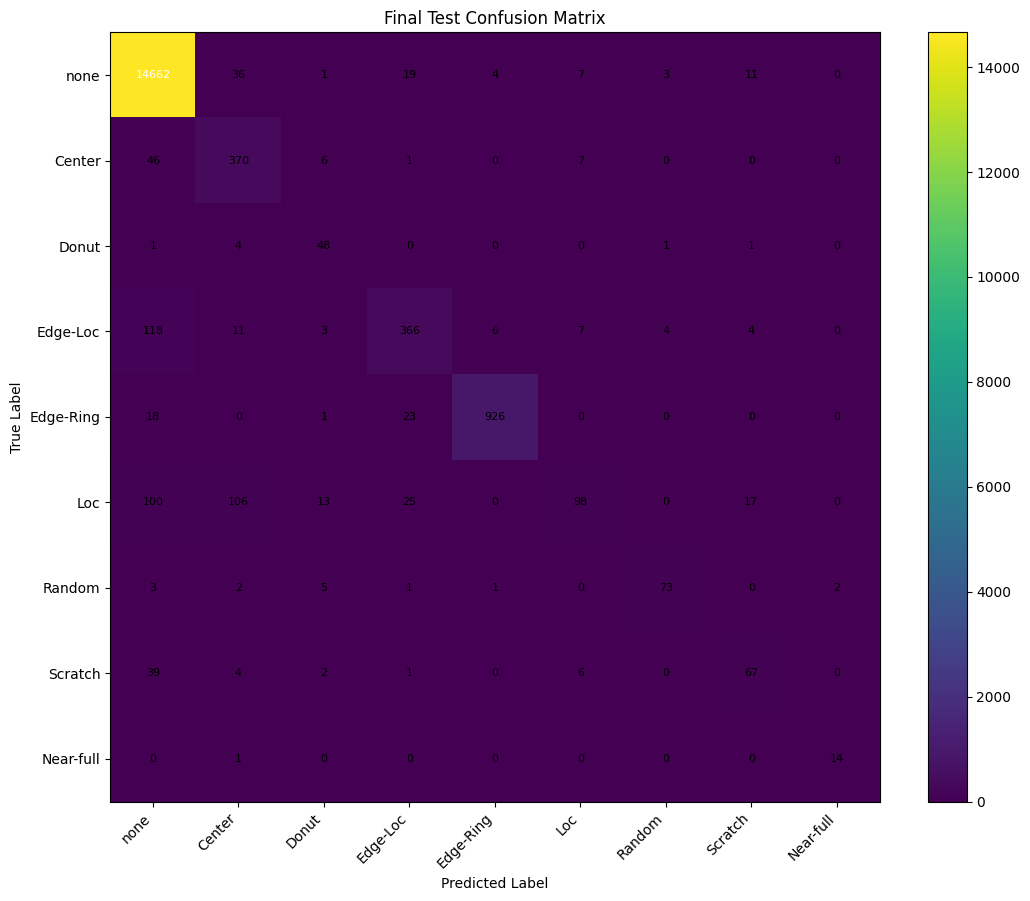

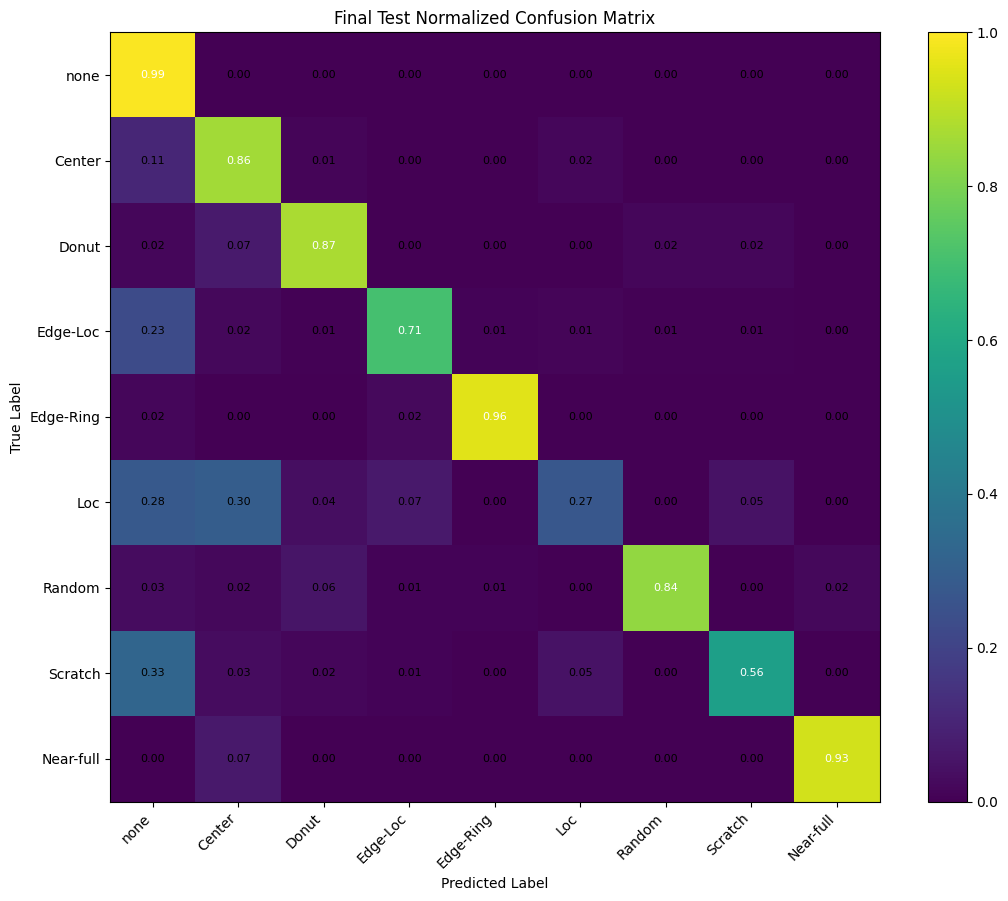



FINAL SUMMARY
                                0
best_epoch              10.000000
validation_macro_f1      0.769266
test_loss                0.399430
test_accuracy            0.961203
test_macro_f1            0.777575
test_weighted_f1         0.957351
test_size            17295.000000

Saved files:
- final_test_summary.csv
- final_test_classification_report.csv
- final_test_per_class_results.csv
- final_test_confusion_matrix.png
- final_test_normalized_confusion_matrix.png

DONE.


In [ ]:
# ============================================================
# FINAL TEST ONLY
#
# 전제:
# - 학습은 이미 완료됨
# - BEST_MODEL_PATH 존재
# - model 존재
# - test_loader 존재
# - criterion 존재
# - DEVICE 존재
# - CLASS_NAMES 존재
#
# 이 코드는 Best checkpoint를 불러와
# held-out Test set을 최종 평가한다.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)


# ============================================================
# 1. Load Best Checkpoint
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False,   # 직접 만든 checkpoint이므로 사용
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)


print("=" * 70)
print("BEST CHECKPOINT LOADED")
print("=" * 70)

print(
    "Checkpoint epoch:",
    checkpoint["epoch"],
)

print(
    "Checkpoint Validation Macro F1:",
    f'{checkpoint["val_macro_f1"]:.4f}',
)


# ============================================================
# 2. Test Evaluation Function
# ============================================================

@torch.no_grad()
def evaluate_test(
    model,
    loader,
    criterion,
):

    model.eval()

    total_loss = 0.0

    all_targets = []
    all_predictions = []

    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True,
        )

        logits = model(images)

        loss = criterion(
            logits,
            labels,
        )

        total_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = torch.argmax(
            logits,
            dim=1,
        )

        all_targets.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )


    test_loss = (
        total_loss
        / len(loader.dataset)
    )

    test_accuracy = accuracy_score(
        all_targets,
        all_predictions,
    )

    test_macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0,
    )

    test_weighted_f1 = f1_score(
        all_targets,
        all_predictions,
        average="weighted",
        zero_division=0,
    )


    return (
        test_loss,
        test_accuracy,
        test_macro_f1,
        test_weighted_f1,
        np.array(all_targets),
        np.array(all_predictions),
    )


# ============================================================
# 3. FINAL HELD-OUT TEST
#
# 여기서 Test set을 최종적으로 평가
# 이후 모델 튜닝 X
# ============================================================

print("\n")
print("#" * 70)
print("FINAL HELD-OUT TEST")
print("#" * 70)


(
    test_loss,
    test_acc,
    test_macro_f1,
    test_weighted_f1,
    y_true,
    y_pred,
) = evaluate_test(
    model,
    test_loader,
    criterion,
)


print("\nFINAL TEST RESULT")
print("=" * 70)

print(
    f"Test Loss        : {test_loss:.4f}"
)

print(
    f"Test Accuracy    : {test_acc:.4f}"
)

print(
    f"Test Macro F1    : {test_macro_f1:.4f}"
)

print(
    f"Test Weighted F1 : {test_weighted_f1:.4f}"
)


# ============================================================
# 4. Classification Report
# ============================================================

print("\nClassification Report\n")


report_text = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
)

print(report_text)


report_dict = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)


# ============================================================
# 5. Per-Class Results
# ============================================================

per_class_results = []

for class_name in CLASS_NAMES:

    metrics = report_dict[class_name]

    per_class_results.append(
        {
            "class": class_name,
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1-score"],
            "support": int(metrics["support"]),
        }
    )


per_class_df = pd.DataFrame(
    per_class_results
)


print("\nPer-class Test Results")
print(
    per_class_df.round(4)
)


per_class_df.to_csv(
    "final_test_per_class_results.csv",
    index=False,
)


# ============================================================
# 6. Raw Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES))),
)


plt.figure(
    figsize=(11, 9)
)

plt.imshow(
    cm,
    interpolation="nearest",
)

plt.title(
    "Final Test Confusion Matrix"
)

plt.colorbar()


ticks = np.arange(
    len(CLASS_NAMES)
)

plt.xticks(
    ticks,
    CLASS_NAMES,
    rotation=45,
    ha="right",
)

plt.yticks(
    ticks,
    CLASS_NAMES,
)


threshold = cm.max() / 2.0


for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        value = cm[i, j]

        plt.text(
            j,
            i,
            str(value),
            horizontalalignment="center",
            verticalalignment="center",
            color=(
                "white"
                if value > threshold
                else "black"
            ),
            fontsize=8,
        )


plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(
    "final_test_confusion_matrix.png",
    dpi=150,
)

plt.show()


# ============================================================
# 7. Normalized Confusion Matrix
# ============================================================

row_sums = cm.sum(
    axis=1,
    keepdims=True,
)


cm_normalized = np.divide(
    cm,
    row_sums,
    out=np.zeros_like(
        cm,
        dtype=float,
    ),
    where=row_sums != 0,
)


plt.figure(
    figsize=(11, 9)
)

plt.imshow(
    cm_normalized,
    interpolation="nearest",
    vmin=0,
    vmax=1,
)

plt.title(
    "Final Test Normalized Confusion Matrix"
)

plt.colorbar()


plt.xticks(
    ticks,
    CLASS_NAMES,
    rotation=45,
    ha="right",
)

plt.yticks(
    ticks,
    CLASS_NAMES,
)


for i in range(
    cm_normalized.shape[0]
):

    for j in range(
        cm_normalized.shape[1]
    ):

        value = cm_normalized[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            horizontalalignment="center",
            verticalalignment="center",
            color=(
                "white"
                if value > 0.5
                else "black"
            ),
            fontsize=8,
        )


plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(
    "final_test_normalized_confusion_matrix.png",
    dpi=150,
)

plt.show()


# ============================================================
# 8. Save Full Classification Report
# ============================================================

report_df = pd.DataFrame(
    report_dict
).T


report_df.to_csv(
    "final_test_classification_report.csv"
)


# ============================================================
# 9. Final Summary
# ============================================================

summary_df = pd.DataFrame(
    [
        {
            "best_epoch":
                checkpoint["epoch"],

            "validation_macro_f1":
                checkpoint["val_macro_f1"],

            "test_loss":
                test_loss,

            "test_accuracy":
                test_acc,

            "test_macro_f1":
                test_macro_f1,

            "test_weighted_f1":
                test_weighted_f1,

            "test_size":
                len(test_loader.dataset),
        }
    ]
)


summary_df.to_csv(
    "final_test_summary.csv",
    index=False,
)


print("\n")
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(
    summary_df.T
)


print("\nSaved files:")
print("- final_test_summary.csv")
print("- final_test_classification_report.csv")
print("- final_test_per_class_results.csv")
print("- final_test_confusion_matrix.png")
print("- final_test_normalized_confusion_matrix.png")


print("\nDONE.")

In [ ]:
import torch
import sys

print("Python:", sys.version)
print("Torch version:", torch.__version__)
print("Torch path:", torch.__file__)
print("Has torch._utils:", hasattr(torch, "_utils"))

try:
    import torch._utils
    print("torch._utils import: OK")
except Exception as e:
    print("torch._utils import ERROR:", repr(e))

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Torch version: 2.11.0+cu128
Torch path: /usr/local/lib/python3.13/dist-packages/torch/__init__.py
Has torch._utils: False
torch._utils import: OK


In [ ]:
!pip install torch

In [ ]:
!pip install --upgrade torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5

In [ ]:
import sys
import torch

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("torch._utils loaded:", hasattr(torch, "_utils"))

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Torch: 2.13.0+cu130
CUDA available: True
CUDA version: 13.0
torch._utils loaded: True


In [ ]:
import torch.nn as nn

model = nn.Linear(10, 2).cuda()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Adam OK")

Adam OK


NameError: name 'train_df' is not defined

In [ ]:
# ============================================================
# WM-811K LOT LEAKAGE CHECK
# 데이터 로드 → 정제 → 기존 80/10/10 split 재현 → lot overlap 확인
#
# 모델 학습은 하지 않음
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split


# ============================================================
# 1. Configuration
# ============================================================

PKL_PATH = "/content/drive/MyDrive/LSWMD.pkl/LSWMD.pkl"
SEED = 42

CLASS_NAMES = [
    "none",
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-full",
]


# ============================================================
# 2. Load WM-811K
# ============================================================

print("=" * 70)
print("LOADING WM-811K")
print("=" * 70)

df = pd.read_pickle(PKL_PATH)

print("Original shape:", df.shape)
print("Columns:")
print(df.columns.tolist())


# ============================================================
# 3. Clean failureType
# ============================================================

def extract_label(value):
    """
    WM-811K failureType에 들어 있는
    numpy array / list / 문자열을 일반 문자열로 변환.
    """

    if isinstance(value, str):
        value = value.strip()
        return value if value else None

    if isinstance(value, (list, tuple, np.ndarray)):

        arr = np.asarray(value)

        if arr.size == 0:
            return None

        value = str(
            arr.flatten()[0]
        ).strip()

        return value if value else None

    return None


df["failureType_clean"] = (
    df["failureType"]
    .apply(extract_label)
)


# 9개 label이 존재하는 wafer만 사용
df = df[
    df["failureType_clean"].isin(CLASS_NAMES)
].copy()


# 원래 dataframe의 index 보존
df["original_index"] = df.index

df = df.reset_index(drop=True)


print("\nClean dataset size:", len(df))

print("\nClass distribution:")

print(
    df["failureType_clean"]
    .value_counts()
    .reindex(CLASS_NAMES)
)


# ============================================================
# 4. 기존 FINAL 실험과 동일하게
# Train 80 / Validation 10 / Test 10
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["failureType_clean"],
)


val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["failureType_clean"],
)


train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)


print("\n" + "=" * 70)
print("REPRODUCED FINAL SPLIT")
print("=" * 70)

print(f"Train      : {len(train_df):,}")
print(f"Validation : {len(val_df):,}")
print(f"Test       : {len(test_df):,}")


# ------------------------------------------------------------
# 최종 실험 당시 숫자와 같은지 확인
# ------------------------------------------------------------

assert len(train_df) == 138360
assert len(val_df) == 17295
assert len(test_df) == 17295

print("\nSplit size check: OK")


# ============================================================
# 5. Class Distribution 확인
# ============================================================

def print_distribution(name, data):

    print(f"\n{name}")

    counts = (
        data["failureType_clean"]
        .value_counts()
        .reindex(CLASS_NAMES)
        .fillna(0)
        .astype(int)
    )

    print(counts)


print_distribution(
    "Train class distribution",
    train_df
)

print_distribution(
    "Validation class distribution",
    val_df
)

print_distribution(
    "Test class distribution",
    test_df
)


# ============================================================
# 6. lotName 정제
#
# NaN을 문자열 "nan"으로 만들어
# 하나의 공통 lot으로 취급하지 않도록 주의
# ============================================================

def clean_lot_name(value):

    if pd.isna(value):
        return None

    value = str(value).strip()

    if (
        value == ""
        or value.lower() in {
            "nan",
            "none",
            "null",
        }
    ):
        return None

    return value


for data in [
    train_df,
    val_df,
    test_df,
]:

    data["lotName_clean"] = (
        data["lotName"]
        .apply(clean_lot_name)
    )


# ============================================================
# 7. Missing lotName 확인
# ============================================================

print("\n" + "=" * 70)
print("MISSING LOT NAME")
print("=" * 70)

for name, data in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df),
]:

    missing = (
        data["lotName_clean"]
        .isna()
        .sum()
    )

    print(
        f"{name:10s}: "
        f"{missing:,} / {len(data):,}"
    )


# ============================================================
# 8. Unique lot set 생성
# ============================================================

def get_lot_set(data):

    return set(
        data["lotName_clean"]
        .dropna()
        .unique()
    )


train_lots = get_lot_set(train_df)
val_lots   = get_lot_set(val_df)
test_lots  = get_lot_set(test_df)


print("\n" + "=" * 70)
print("UNIQUE LOT COUNT")
print("=" * 70)

print(
    f"Train unique lots      : "
    f"{len(train_lots):,}"
)

print(
    f"Validation unique lots : "
    f"{len(val_lots):,}"
)

print(
    f"Test unique lots       : "
    f"{len(test_lots):,}"
)


# ============================================================
# 9. Lot overlap
# ============================================================

train_val_overlap = (
    train_lots & val_lots
)

train_test_overlap = (
    train_lots & test_lots
)

val_test_overlap = (
    val_lots & test_lots
)

all_three_overlap = (
    train_lots
    & val_lots
    & test_lots
)


print("\n" + "=" * 70)
print("LOT OVERLAP")
print("=" * 70)

print(
    f"Train ∩ Validation : "
    f"{len(train_val_overlap):,} lots"
)

print(
    f"Train ∩ Test       : "
    f"{len(train_test_overlap):,} lots"
)

print(
    f"Validation ∩ Test  : "
    f"{len(val_test_overlap):,} lots"
)

print(
    f"Train ∩ Val ∩ Test : "
    f"{len(all_three_overlap):,} lots"
)


# ============================================================
# 10. Test의 lot 중 Train에서 본 lot 비율
# ============================================================

seen_test_lots = (
    test_lots & train_lots
)

unseen_test_lots = (
    test_lots - train_lots
)


print("\n" + "=" * 70)
print("TEST LOT GENERALIZATION")
print("=" * 70)

print(
    f"Test lots seen in Train : "
    f"{len(seen_test_lots):,}"
)

print(
    f"Unseen Test lots        : "
    f"{len(unseen_test_lots):,}"
)


if len(test_lots) > 0:

    seen_lot_ratio = (
        len(seen_test_lots)
        / len(test_lots)
    )

    unseen_lot_ratio = (
        len(unseen_test_lots)
        / len(test_lots)
    )

    print(
        f"\nSeen Test lot ratio   : "
        f"{seen_lot_ratio:.2%}"
    )

    print(
        f"Unseen Test lot ratio : "
        f"{unseen_lot_ratio:.2%}"
    )


# ============================================================
# 11. 더 중요한 지표:
# Test wafer 자체가 Train에서 본 lot에서 나온 비율
# ============================================================

valid_test_mask = (
    test_df["lotName_clean"]
    .notna()
)

valid_test_df = (
    test_df[valid_test_mask]
    .copy()
)


test_from_seen_lot = (
    valid_test_df["lotName_clean"]
    .isin(train_lots)
)


seen_wafer_count = int(
    test_from_seen_lot.sum()
)

unseen_wafer_count = int(
    (~test_from_seen_lot).sum()
)


print("\n" + "=" * 70)
print("TEST WAFER EXPOSURE")
print("=" * 70)

print(
    "Test wafers from Train-seen lots : "
    f"{seen_wafer_count:,}"
)

print(
    "Test wafers from unseen lots     : "
    f"{unseen_wafer_count:,}"
)


if len(valid_test_df) > 0:

    print(
        "\nTrain-seen lot wafer ratio : "
        f"{seen_wafer_count / len(valid_test_df):.2%}"
    )

    print(
        "Unseen lot wafer ratio     : "
        f"{unseen_wafer_count / len(valid_test_df):.2%}"
    )


# ============================================================
# 12. 동일 wafer 자체가 중복됐는지도 확인
#
# 이건 현재 split 방식상 0이어야 정상
# ============================================================

train_indices = set(
    train_df["original_index"]
)

val_indices = set(
    val_df["original_index"]
)

test_indices = set(
    test_df["original_index"]
)


print("\n" + "=" * 70)
print("EXACT WAFER OVERLAP")
print("=" * 70)

print(
    "Train ∩ Validation :",
    len(train_indices & val_indices)
)

print(
    "Train ∩ Test       :",
    len(train_indices & test_indices)
)

print(
    "Validation ∩ Test  :",
    len(val_indices & test_indices)
)


# ============================================================
# 13. Train/Test 양쪽에 존재하는 lot 예시
# ============================================================

train_lot_counts = (
    train_df["lotName_clean"]
    .dropna()
    .value_counts()
)

test_lot_counts = (
    test_df["lotName_clean"]
    .dropna()
    .value_counts()
)


overlap_df = pd.DataFrame(
    {
        "train_wafer_count":
            train_lot_counts,

        "test_wafer_count":
            test_lot_counts,
    }
).fillna(0)


overlap_df = overlap_df[
    (overlap_df["train_wafer_count"] > 0)
    &
    (overlap_df["test_wafer_count"] > 0)
].copy()


overlap_df["total"] = (
    overlap_df["train_wafer_count"]
    +
    overlap_df["test_wafer_count"]
)


overlap_df = (
    overlap_df
    .sort_values(
        "total",
        ascending=False,
    )
)


print("\n" + "=" * 70)
print("TOP 20 OVERLAPPING TRAIN / TEST LOTS")
print("=" * 70)

print(
    overlap_df
    .head(20)
    .astype(int)
)


# ============================================================
# 14. 최종 간단 판정
# ============================================================

print("\n" + "=" * 70)
print("QUICK INTERPRETATION")
print("=" * 70)


if len(train_test_overlap) == 0:

    print(
        "GOOD: Train과 Test 사이에 "
        "공통 lot이 없습니다."
    )

    print(
        "현재 Test는 lot-disjoint evaluation입니다."
    )

else:

    ratio = (
        seen_wafer_count
        / len(valid_test_df)
        if len(valid_test_df) > 0
        else 0
    )

    print(
        f"Train과 Test에 공통 lot이 "
        f"{len(train_test_overlap):,}개 있습니다."
    )

    print(
        f"유효한 Test wafer 중 "
        f"{ratio:.2%}가 Train에서 이미 본 lot에 속합니다."
    )

    print(
        "따라서 현재 Test 결과는 "
        "'wafer-level held-out test'로는 유효하지만, "
        "'unseen lot generalization'을 증명하지는 않습니다."
    )


print("\nDONE.")

LOADING WM-811K
Original shape: (811457, 6)
Columns:
['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']

Clean dataset size: 172950

Class distribution:
failureType_clean
none         147431
Center         4294
Donut           555
Edge-Loc       5189
Edge-Ring      9680
Loc            3593
Random          866
Scratch        1193
Near-full       149
Name: count, dtype: int64

REPRODUCED FINAL SPLIT
Train      : 138,360
Validation : 17,295
Test       : 17,295

Split size check: OK

Train class distribution
failureType_clean
none         117945
Center         3435
Donut           444
Edge-Loc       4151
Edge-Ring      7744
Loc            2875
Random          693
Scratch         954
Near-full       119
Name: count, dtype: int64

Validation class distribution
failureType_clean
none         14743
Center         429
Donut           56
Edge-Loc       519
Edge-Ring      968
Loc            359
Random          86
Scratch        120
Near-full       15
Name: count, dt

In [ ]:
# ============================================================
# WM-811K PRE-TRAINING AUDIT
#
# 목적
# 1. Dataset official Training/Test split 확인
# 2. Official split에서도 lot overlap이 있는지 확인
# 3. Class별 unique lot 수 확인
# 4. Raw wafer map exact duplicate 확인
# 5. 서로 다른 lot 사이 duplicate 확인
# 6. 동일 map인데 서로 다른 label이 붙은 사례 확인
# 7. wafer geometry/shape 분포 확인
# ============================================================

import hashlib
import numpy as np
import pandas as pd


CLASS_NAMES = [
    "none",
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-full",
]


# ============================================================
# 1. Helpers
# ============================================================

def unwrap(value):
    """
    nested numpy/list 값을 일반 문자열로 변환.
    """
    if isinstance(value, str):
        v = value.strip()
        return v if v else None

    if isinstance(value, (list, tuple, np.ndarray)):
        arr = np.asarray(value)

        if arr.size == 0:
            return None

        v = str(arr.reshape(-1)[0]).strip()
        return v if v else None

    return None


def normalize_split_label(value):

    v = unwrap(value)

    if v is None:
        return None

    v = v.lower()

    if v == "training":
        return "Training"

    if v == "test":
        return "Test"

    return v


def wafer_hash(wafer):
    """
    Shape + raw categorical map을 함께 hash.
    shape가 다른 array가 우연히 같은 byte sequence를
    가지는 것을 방지.
    """

    arr = np.asarray(
        wafer,
        dtype=np.uint8
    )

    arr = np.ascontiguousarray(arr)

    h = hashlib.blake2b(
        digest_size=16
    )

    h.update(
        str(arr.shape).encode()
    )

    h.update(
        arr.tobytes()
    )

    return h.hexdigest()


# ============================================================
# 2. Basic dataset check
# ============================================================

print("=" * 70)
print("DATASET AUDIT")
print("=" * 70)

print("Rows:", len(df))
print("Columns:", df.columns.tolist())


# 필요하다면 clean label 다시 확인
if "failureType_clean" not in df.columns:

    df["failureType_clean"] = (
        df["failureType"].apply(unwrap)
    )


audit_df = df[
    df["failureType_clean"].isin(CLASS_NAMES)
].copy()


print("\nLabeled rows:", len(audit_df))


# ============================================================
# 3. Original Training/Test label
# ============================================================

split_col = None

for candidate in [
    "trianTestLabel",
    "trainTestLabel",
]:

    if candidate in audit_df.columns:
        split_col = candidate
        break


if split_col is None:

    print("\nNo original train/test column found.")

else:

    audit_df["official_split"] = (
        audit_df[split_col]
        .apply(normalize_split_label)
    )


    print("\n" + "=" * 70)
    print("OFFICIAL SPLIT")
    print("=" * 70)

    print(
        audit_df["official_split"]
        .value_counts(
            dropna=False
        )
    )


    print("\nOfficial split by class:")

    print(
        pd.crosstab(
            audit_df["failureType_clean"],
            audit_df["official_split"],
        ).reindex(CLASS_NAMES)
    )


# ============================================================
# 4. Class -> unique lot count
#
# Rare class가 실제로 몇 개의 lot에 걸쳐 존재하는지 확인.
# Near-full 149개가 2~3 lot에만 몰려 있다면
# group split 설계가 매우 어려워진다.
# ============================================================

print("\n" + "=" * 70)
print("UNIQUE LOTS PER CLASS")
print("=" * 70)

class_lot_stats = (
    audit_df
    .groupby("failureType_clean")
    .agg(
        samples=("lotName", "size"),
        unique_lots=("lotName", "nunique"),
    )
    .reindex(CLASS_NAMES)
)

class_lot_stats["samples_per_lot"] = (
    class_lot_stats["samples"]
    /
    class_lot_stats["unique_lots"]
)

print(
    class_lot_stats.round(2)
)


# ============================================================
# 5. Lot size statistics
# ============================================================

lot_size = (
    audit_df
    .groupby("lotName")
    .size()
)


print("\n" + "=" * 70)
print("LOT SIZE")
print("=" * 70)

print(
    lot_size.describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)


# ============================================================
# 6. Official split lot overlap
# ============================================================

if split_col is not None:

    official_train = audit_df[
        audit_df["official_split"]
        == "Training"
    ]

    official_test = audit_df[
        audit_df["official_split"]
        == "Test"
    ]


    train_lots = set(
        official_train["lotName"].unique()
    )

    test_lots = set(
        official_test["lotName"].unique()
    )

    overlap = (
        train_lots & test_lots
    )


    print("\n" + "=" * 70)
    print("OFFICIAL TRAIN / TEST LOT OVERLAP")
    print("=" * 70)

    print(
        "Official Training lots:",
        len(train_lots)
    )

    print(
        "Official Test lots:",
        len(test_lots)
    )

    print(
        "Overlap lots:",
        len(overlap)
    )


    if len(test_lots) > 0:

        print(
            "Test-lot overlap ratio:",
            f"{len(overlap) / len(test_lots):.2%}"
        )


    test_from_seen_lot = (
        official_test["lotName"]
        .isin(train_lots)
    )


    if len(official_test) > 0:

        print(
            "Official Test wafers "
            "from Training-seen lots:",
            f"{test_from_seen_lot.mean():.2%}"
        )


# ============================================================
# 7. Raw wafer exact hashes
# ============================================================

print("\n" + "=" * 70)
print("RAW WAFER HASHING")
print("=" * 70)

print(
    "Calculating hashes... "
    "This can take a little while."
)


audit_df["raw_hash"] = (
    audit_df["waferMap"]
    .apply(wafer_hash)
)


unique_maps = (
    audit_df["raw_hash"]
    .nunique()
)

duplicate_rows = (
    len(audit_df) - unique_maps
)


print("\nTotal rows:", len(audit_df))
print("Unique raw wafer maps:", unique_maps)
print("Duplicate rows:", duplicate_rows)

print(
    "Duplicate row ratio:",
    f"{duplicate_rows / len(audit_df):.4%}"
)


# ============================================================
# 8. Duplicate hash statistics
# ============================================================

hash_counts = (
    audit_df["raw_hash"]
    .value_counts()
)


duplicate_hashes = (
    hash_counts[
        hash_counts > 1
    ]
    .index
)


duplicate_df = audit_df[
    audit_df["raw_hash"]
    .isin(duplicate_hashes)
].copy()


print("\nDuplicate hash groups:")
print(len(duplicate_hashes))


# ============================================================
# 9. Duplicate maps across different LOTS
# ============================================================

if len(duplicate_df) > 0:

    duplicate_lot_stats = (
        duplicate_df
        .groupby("raw_hash")
        ["lotName"]
        .nunique()
    )

    cross_lot_hashes = (
        duplicate_lot_stats[
            duplicate_lot_stats > 1
        ]
        .index
    )


    print(
        "\nDuplicate maps appearing "
        "in >1 lot:",
        len(cross_lot_hashes)
    )


    cross_lot_rows = duplicate_df[
        duplicate_df["raw_hash"]
        .isin(cross_lot_hashes)
    ]


    print(
        "Rows involved in "
        "cross-lot duplicates:",
        len(cross_lot_rows)
    )


# ============================================================
# 10. Same wafer map but conflicting labels
# ============================================================

if len(duplicate_df) > 0:

    label_per_hash = (
        duplicate_df
        .groupby("raw_hash")
        ["failureType_clean"]
        .nunique()
    )


    conflicting_hashes = (
        label_per_hash[
            label_per_hash > 1
        ]
        .index
    )


    print("\n" + "=" * 70)
    print("LABEL CONFLICT CHECK")
    print("=" * 70)

    print(
        "Identical maps with "
        "multiple labels:",
        len(conflicting_hashes)
    )


    if len(conflicting_hashes) > 0:

        conflict_examples = (
            duplicate_df[
                duplicate_df["raw_hash"]
                .isin(conflicting_hashes)
            ]
            [
                [
                    "raw_hash",
                    "lotName",
                    "waferIndex",
                    "failureType_clean",
                ]
            ]
            .sort_values("raw_hash")
        )

        print(
            "\nConflict examples:"
        )

        print(
            conflict_examples.head(30)
        )


# ============================================================
# 11. Geometry check
#
# wafer size/shape가 class마다 특정하게 몰리는지 확인
# ============================================================

audit_df["map_height"] = (
    audit_df["waferMap"]
    .apply(
        lambda x: np.asarray(x).shape[0]
    )
)

audit_df["map_width"] = (
    audit_df["waferMap"]
    .apply(
        lambda x: np.asarray(x).shape[1]
    )
)


audit_df["map_shape"] = (
    audit_df["map_height"].astype(str)
    + "x"
    + audit_df["map_width"].astype(str)
)


print("\n" + "=" * 70)
print("WAFER GEOMETRY")
print("=" * 70)

print(
    audit_df[
        [
            "map_height",
            "map_width",
            "dieSize",
        ]
    ]
    .describe()
)


print("\nUnique map shapes per class:")

shape_by_class = (
    audit_df
    .groupby("failureType_clean")
    ["map_shape"]
    .nunique()
    .reindex(CLASS_NAMES)
)

print(shape_by_class)


# 각 class에서 가장 흔한 shape
print("\nMost common shapes by class:")

for cls in CLASS_NAMES:

    subset = audit_df[
        audit_df["failureType_clean"]
        == cls
    ]

    top_shapes = (
        subset["map_shape"]
        .value_counts()
        .head(5)
    )

    print(f"\n[{cls}]")
    print(top_shapes)


# ============================================================
# 12. Lot purity
#
# 한 lot에 한 class만 있는지,
# 여러 failureType이 섞이는지 확인.
# ============================================================

lot_class_counts = (
    audit_df
    .groupby("lotName")
    ["failureType_clean"]
    .nunique()
)


print("\n" + "=" * 70)
print("CLASSES PER LOT")
print("=" * 70)

print(
    lot_class_counts
    .value_counts()
    .sort_index()
)


print(
    "\nMean classes per lot:",
    round(
        lot_class_counts.mean(),
        3
    )
)


print("\nAUDIT COMPLETE.")

DATASET AUDIT
Rows: 172950
Columns: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType', 'failureType_clean', 'original_index']

Labeled rows: 172950

OFFICIAL SPLIT
official_split
Test        118595
Training     54355
Name: count, dtype: int64

Official split by class:
official_split       Test  Training
failureType_clean                  
none               110701     36730
Center                832      3462
Donut                 146       409
Edge-Loc             2772      2417
Edge-Ring            1126      8554
Loc                  1973      1620
Random                257       609
Scratch               693       500
Near-full              95        54

UNIQUE LOTS PER CLASS
                   samples  unique_lots  samples_per_lot
failureType_clean                                       
none                147431         6591            22.37
Center                4294         1648             2.61
Donut                  555          233             2

WM-811K FINAL CONFIRMATORY EXPERIMENT
PyTorch: 2.11.0+cu128
Device: cuda

Loading WM-811K...
Original shape: (811457, 6)
Labeled dataset: 172950

Calculating raw hashes...

Raw conflicting hash groups: 14
Rows removed: 28

Calculating processed 64x64 hashes...
This can take a few minutes.

Processed conflicting groups: 0
Rows removed: 0

OFFICIAL SPLIT
Official Training: 54341
Official Test: 118581

Official Train/Test lot overlap: 0

Official Test raw-map overlap rows: 3144
Official Test processed-input overlap rows: 3144

Strict unseen-input Test: 115437
Removed from Official Test: 3144

LOT-DISJOINT DEVELOPMENT SPLIT
Selected fold: 3
Train candidate: 43441
Validation candidate: 10900

Train/Val processed overlap rows: 11

LOT overlap checks: PASS
Processed-input overlap checks: PASS

FINAL TRAIN: 43,441
failureType_clean
none         29372
Center        2717
Donut          337
Edge-Loc      1963
Edge-Ring     6803
Loc           1289
Random         530
Scratch        389
Near-full   

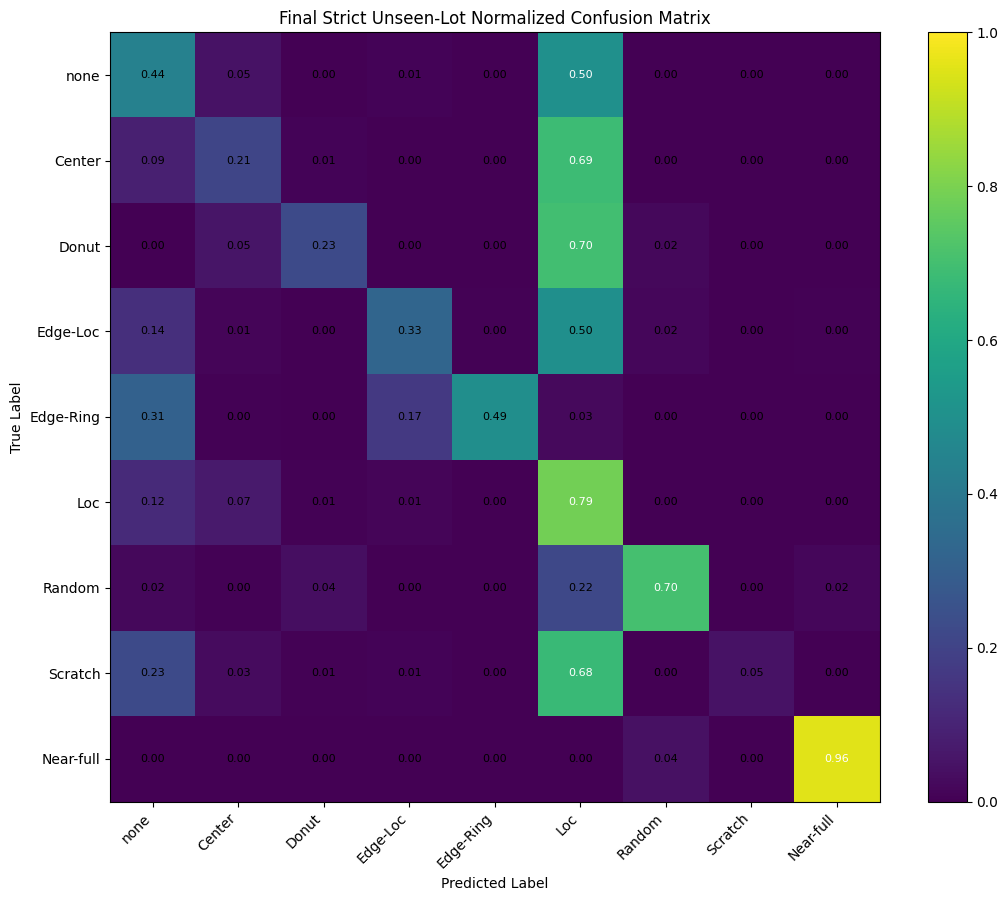



EXPERIMENT COMPLETE
                                     0
official_train_original          54341
official_test_original          118581
final_train                      43441
final_validation                 10889
strict_test                     115437
train_test_lot_overlap               0
processed_input_overlap              0
always_none_accuracy          0.932491
always_none_macro_f1           0.10723
geometry_test_accuracy        0.122534
geometry_test_macro_f1        0.049178
final_method                  WCE_SQRT
representative_seed                123
final_test_accuracy           0.438126
final_test_macro_f1            0.41146
final_test_macro_recall       0.465409
final_test_weighted_f1        0.582385
final_test_balanced_accuracy  0.465409

Results saved in:
wm811k_final_results/


In [ ]:
# ============================================================
# WM-811K FINAL CONFIRMATORY EXPERIMENT
#
# 1. Official Training / Test split 사용
# 2. Official Test와 Train은 lot-disjoint인지 검증
# 3. 동일 input + conflicting labels 제거
# 4. Train 내부에서 StratifiedGroupKFold로 lot-disjoint validation
# 5. Train/Val/Test 간 processed input exact duplicate 제거
# 6. Aspect-ratio preserving nearest resize + zero padding
# 7. Geometry-only sanity baseline
# 8. Standard CE vs sqrt-inverse Weighted CE
# 9. seeds = 42, 123, 2026
# 10. Validation Macro F1 + Early Stopping
# 11. Official unseen-lot Test 평가
#
# Test 결과 확인 후 실험 조건 변경 X
# ============================================================


# ============================================================
# 0. Imports
# ============================================================

import os
import copy
import random
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedGroupKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

from sklearn.ensemble import RandomForestClassifier


warnings.filterwarnings("ignore")


# ============================================================
# 1. Configuration
# ============================================================

PKL_PATH = "/content/drive/MyDrive/LSWMD.pkl/LSWMD.pkl"

IMG_SIZE = 64
BATCH_SIZE = 128

MAX_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5

LEARNING_RATE = 1e-3

NUM_WORKERS = 2

SPLIT_SEED = 42

TRAINING_SEEDS = [
    42,
    123,
    2026,
]

CLASS_NAMES = [
    "none",
    "Center",
    "Donut",
    "Edge-Loc",
    "Edge-Ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-full",
]

LABEL_TO_IDX = {
    name: idx
    for idx, name
    in enumerate(CLASS_NAMES)
}

NUM_CLASSES = len(CLASS_NAMES)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

os.makedirs(
    "wm811k_final_results",
    exist_ok=True,
)


print("=" * 80)
print("WM-811K FINAL CONFIRMATORY EXPERIMENT")
print("=" * 80)

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)


# ============================================================
# 2. Seed
# ============================================================

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================================
# 3. Label helpers
# ============================================================

def unwrap(value):

    if isinstance(value, str):

        value = value.strip()

        return (
            value
            if value
            else None
        )

    if isinstance(
        value,
        (list, tuple, np.ndarray)
    ):

        arr = np.asarray(value)

        if arr.size == 0:
            return None

        value = str(
            arr.reshape(-1)[0]
        ).strip()

        return (
            value
            if value
            else None
        )

    return None


def normalize_split_label(value):

    value = unwrap(value)

    if value is None:
        return None

    value = value.lower()

    if value == "training":
        return "Training"

    if value == "test":
        return "Test"

    return value


# ============================================================
# 4. Raw map hash
# ============================================================

def raw_wafer_hash(wafer):

    arr = np.asarray(
        wafer,
        dtype=np.uint8,
    )

    arr = np.ascontiguousarray(arr)

    h = hashlib.blake2b(
        digest_size=16
    )

    h.update(
        str(arr.shape).encode()
    )

    h.update(
        arr.tobytes()
    )

    return h.hexdigest()


# ============================================================
# 5. FINAL preprocessing
#
# Aspect ratio 유지
# nearest interpolation
# 64x64 center padding
#
# 반환:
# categorical [64,64]
# ============================================================

def preprocess_categorical_map(
    wafer,
    img_size=IMG_SIZE,
):

    arr = np.asarray(
        wafer,
        dtype=np.uint8,
    )

    if arr.ndim != 2:
        raise ValueError(
            f"waferMap must be 2D, got {arr.shape}"
        )

    h, w = arr.shape

    scale = min(
        img_size / h,
        img_size / w,
    )

    new_h = max(
        1,
        int(round(h * scale))
    )

    new_w = max(
        1,
        int(round(w * scale))
    )

    tensor = (
        torch.from_numpy(arr)
        .float()
        .unsqueeze(0)
        .unsqueeze(0)
    )

    resized = F.interpolate(
        tensor,
        size=(new_h, new_w),
        mode="nearest",
    )

    resized = (
        resized
        .squeeze(0)
        .squeeze(0)
        .to(torch.uint8)
    )

    canvas = torch.zeros(
        (img_size, img_size),
        dtype=torch.uint8,
    )

    top = (
        img_size - new_h
    ) // 2

    left = (
        img_size - new_w
    ) // 2

    canvas[
        top:top + new_h,
        left:left + new_w
    ] = resized

    return canvas


def processed_hash(wafer):

    canvas = preprocess_categorical_map(
        wafer
    )

    arr = (
        canvas
        .numpy()
    )

    h = hashlib.blake2b(
        digest_size=16
    )

    h.update(
        arr.tobytes()
    )

    return h.hexdigest()


# ============================================================
# 6. Load Dataset
# ============================================================

print("\nLoading WM-811K...")

df = pd.read_pickle(
    PKL_PATH
)

print(
    "Original shape:",
    df.shape
)


df["failureType_clean"] = (
    df["failureType"]
    .apply(unwrap)
)


split_col = (
    "trianTestLabel"
    if "trianTestLabel" in df.columns
    else "trainTestLabel"
)


df["official_split"] = (
    df[split_col]
    .apply(normalize_split_label)
)


df = df[
    df["failureType_clean"]
    .isin(CLASS_NAMES)
].copy()


df["original_index"] = df.index

df = df.reset_index(
    drop=True
)


print(
    "Labeled dataset:",
    len(df)
)


# ============================================================
# 7. Raw hashes
# ============================================================

print("\nCalculating raw hashes...")

df["raw_hash"] = (
    df["waferMap"]
    .apply(raw_wafer_hash)
)


# ============================================================
# 8. Remove conflicting raw labels
#
# 완전히 같은 raw map인데 label이 2개 이상이면
# ambiguous supervision이므로 전체 제거
# ============================================================

raw_label_count = (
    df.groupby("raw_hash")
    ["failureType_clean"]
    .nunique()
)


raw_conflict_hashes = set(
    raw_label_count[
        raw_label_count > 1
    ].index
)


print(
    "\nRaw conflicting hash groups:",
    len(raw_conflict_hashes)
)


before = len(df)

df = df[
    ~df["raw_hash"]
    .isin(raw_conflict_hashes)
].copy()


print(
    "Rows removed:",
    before - len(df)
)


# ============================================================
# 9. Processed hashes
#
# 실제 CNN이 보는 64x64 input 기준
# collision 검사
# ============================================================

print(
    "\nCalculating processed 64x64 hashes..."
)

print(
    "This can take a few minutes."
)


df["processed_hash"] = (
    df["waferMap"]
    .apply(processed_hash)
)


# ============================================================
# 10. Remove processed-label conflicts
#
# raw map은 달라도 64x64 변환 후 완전히 같아지고
# 서로 다른 label을 가지면 제거
# ============================================================

processed_label_count = (
    df.groupby("processed_hash")
    ["failureType_clean"]
    .nunique()
)


processed_conflict_hashes = set(
    processed_label_count[
        processed_label_count > 1
    ].index
)


print(
    "\nProcessed conflicting groups:",
    len(processed_conflict_hashes)
)


before = len(df)

df = df[
    ~df["processed_hash"]
    .isin(processed_conflict_hashes)
].copy()


print(
    "Rows removed:",
    before - len(df)
)


# ============================================================
# 11. Official split
# ============================================================

official_train = (
    df[
        df["official_split"]
        == "Training"
    ]
    .copy()
    .reset_index(drop=True)
)


official_test = (
    df[
        df["official_split"]
        == "Test"
    ]
    .copy()
    .reset_index(drop=True)
)


print("\n" + "=" * 80)
print("OFFICIAL SPLIT")
print("=" * 80)

print(
    "Official Training:",
    len(official_train)
)

print(
    "Official Test:",
    len(official_test)
)


# ============================================================
# 12. Confirm LOT independence
# ============================================================

official_train_lots = set(
    official_train["lotName"]
)

official_test_lots = set(
    official_test["lotName"]
)


lot_overlap = (
    official_train_lots
    & official_test_lots
)


print(
    "\nOfficial Train/Test lot overlap:",
    len(lot_overlap)
)


assert len(lot_overlap) == 0, (
    "ERROR: Official Train/Test lots overlap."
)


# ============================================================
# 13. Raw / processed input overlap audit
# ============================================================

train_raw_hashes = set(
    official_train["raw_hash"]
)

train_processed_hashes = set(
    official_train["processed_hash"]
)


raw_overlap_mask = (
    official_test["raw_hash"]
    .isin(train_raw_hashes)
)


processed_overlap_mask = (
    official_test["processed_hash"]
    .isin(train_processed_hashes)
)


print(
    "\nOfficial Test raw-map overlap rows:",
    int(raw_overlap_mask.sum())
)

print(
    "Official Test processed-input overlap rows:",
    int(processed_overlap_mask.sum())
)


# ============================================================
# 14. STRICT official test
#
# Development data에서 본 processed input과
# 완전히 동일한 Test input은 제외
# ============================================================

strict_test = (
    official_test[
        ~processed_overlap_mask
    ]
    .copy()
    .reset_index(drop=True)
)


print(
    "\nStrict unseen-input Test:",
    len(strict_test)
)

print(
    "Removed from Official Test:",
    len(official_test) - len(strict_test)
)


# ============================================================
# 15. StratifiedGroupKFold
#
# Official Training 안에서만 validation 생성.
#
# lotName 완전 분리.
#
# 5 fold 중 class distribution이
# 전체 official train과 가장 유사한 fold 선택.
# ============================================================

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SPLIT_SEED,
)


y_dev = (
    official_train[
        "failureType_clean"
    ].values
)

groups_dev = (
    official_train[
        "lotName"
    ].values
)


overall_prop = (
    official_train[
        "failureType_clean"
    ]
    .value_counts(
        normalize=True
    )
    .reindex(CLASS_NAMES)
    .fillna(0)
)


fold_candidates = []


for fold, (
    train_idx,
    val_idx,
) in enumerate(
    sgkf.split(
        official_train,
        y_dev,
        groups_dev,
    )
):

    fold_val = (
        official_train
        .iloc[val_idx]
    )

    counts = (
        fold_val[
            "failureType_clean"
        ]
        .value_counts()
        .reindex(CLASS_NAMES)
        .fillna(0)
    )

    # 모든 class가 validation에 있어야 함
    if (counts == 0).any():
        continue

    val_prop = (
        counts / counts.sum()
    )

    distribution_error = (
        np.abs(
            val_prop.values
            - overall_prop.values
        )
        .sum()
    )

    target_ratio_error = abs(
        len(val_idx)
        / len(official_train)
        - 0.20
    )

    score = (
        distribution_error
        + target_ratio_error
    )

    fold_candidates.append(
        (
            score,
            fold,
            train_idx,
            val_idx,
        )
    )


if not fold_candidates:

    raise RuntimeError(
        "No valid StratifiedGroupKFold "
        "containing all classes."
    )


fold_candidates.sort(
    key=lambda x: x[0]
)


(
    split_score,
    chosen_fold,
    train_idx,
    val_idx,
) = fold_candidates[0]


train_df = (
    official_train
    .iloc[train_idx]
    .copy()
    .reset_index(drop=True)
)


val_df = (
    official_train
    .iloc[val_idx]
    .copy()
    .reset_index(drop=True)
)


print("\n" + "=" * 80)
print("LOT-DISJOINT DEVELOPMENT SPLIT")
print("=" * 80)

print(
    "Selected fold:",
    chosen_fold
)

print(
    "Train candidate:",
    len(train_df)
)

print(
    "Validation candidate:",
    len(val_df)
)


# ============================================================
# 16. Guarantee processed input independence
#
# 같은 64x64 input이 Train/Val 양쪽에 있으면
# Validation 쪽에서 제거
# ============================================================

train_input_hashes = set(
    train_df["processed_hash"]
)


val_overlap_mask = (
    val_df["processed_hash"]
    .isin(train_input_hashes)
)


print(
    "\nTrain/Val processed overlap rows:",
    int(
        val_overlap_mask.sum()
    )
)


val_df = (
    val_df[
        ~val_overlap_mask
    ]
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# 17. Final independence assertions
# ============================================================

train_lots = set(
    train_df["lotName"]
)

val_lots = set(
    val_df["lotName"]
)

test_lots = set(
    strict_test["lotName"]
)


assert len(
    train_lots & val_lots
) == 0


assert len(
    train_lots & test_lots
) == 0


assert len(
    val_lots & test_lots
) == 0


assert len(
    set(train_df["processed_hash"])
    &
    set(val_df["processed_hash"])
) == 0


assert len(
    set(official_train["processed_hash"])
    &
    set(strict_test["processed_hash"])
) == 0


print("\nLOT overlap checks: PASS")
print("Processed-input overlap checks: PASS")


# ============================================================
# 18. Final class distributions
# ============================================================

def print_class_distribution(
    name,
    dataframe,
):

    counts = (
        dataframe[
            "failureType_clean"
        ]
        .value_counts()
        .reindex(CLASS_NAMES)
        .fillna(0)
        .astype(int)
    )

    print(
        f"\n{name}: {len(dataframe):,}"
    )

    print(counts)

    return counts


train_counts = print_class_distribution(
    "FINAL TRAIN",
    train_df,
)

val_counts = print_class_distribution(
    "FINAL VALIDATION",
    val_df,
)

test_counts = print_class_distribution(
    "STRICT OFFICIAL TEST",
    strict_test,
)


assert (
    train_counts > 0
).all()

assert (
    val_counts > 0
).all()

assert (
    test_counts > 0
).all()


# ============================================================
# 19. Save split information
# ============================================================

split_info = pd.concat(
    [
        train_df.assign(
            final_split="train"
        ),
        val_df.assign(
            final_split="validation"
        ),
        strict_test.assign(
            final_split="test"
        ),
    ],
    ignore_index=True,
)


split_info[
    [
        "original_index",
        "lotName",
        "waferIndex",
        "failureType_clean",
        "official_split",
        "raw_hash",
        "processed_hash",
        "final_split",
    ]
].to_csv(
    "wm811k_final_results/"
    "final_strict_split.csv",
    index=False,
)


# ============================================================
# 20. ALWAYS-NONE BASELINE
#
# Accuracy가 얼마나 기만적일 수 있는지 확인
# ============================================================

test_true = np.array(
    [
        LABEL_TO_IDX[x]
        for x in strict_test[
            "failureType_clean"
        ]
    ]
)


always_none_pred = np.zeros_like(
    test_true
)


always_none_acc = accuracy_score(
    test_true,
    always_none_pred,
)


always_none_f1 = f1_score(
    test_true,
    always_none_pred,
    average="macro",
    zero_division=0,
)


print("\n" + "=" * 80)
print("ALWAYS-NONE BASELINE")
print("=" * 80)

print(
    f"Accuracy : "
    f"{always_none_acc:.4f}"
)

print(
    f"Macro F1 : "
    f"{always_none_f1:.4f}"
)


# ============================================================
# 21. GEOMETRY-ONLY BASELINE
#
# CNN이 단순 wafer geometry shortcut을
# 이용하는지 확인하는 sanity baseline.
#
# image pattern 사용 X
# height, width, dieSize, aspect ratio, area만 사용.
# ============================================================

def geometry_features(
    dataframe,
):

    heights = (
        dataframe["waferMap"]
        .apply(
            lambda x:
            np.asarray(x).shape[0]
        )
        .astype(float)
    )

    widths = (
        dataframe["waferMap"]
        .apply(
            lambda x:
            np.asarray(x).shape[1]
        )
        .astype(float)
    )

    die_size = (
        dataframe["dieSize"]
        .astype(float)
    )

    aspect_ratio = (
        widths
        / np.maximum(
            heights,
            1
        )
    )

    bounding_area = (
        heights * widths
    )

    return np.column_stack(
        [
            heights,
            widths,
            die_size,
            aspect_ratio,
            bounding_area,
        ]
    )


X_geo_train = geometry_features(
    train_df
)

X_geo_val = geometry_features(
    val_df
)

X_geo_test = geometry_features(
    strict_test
)


y_train_geo = (
    train_df[
        "failureType_clean"
    ]
    .map(LABEL_TO_IDX)
    .values
)

y_val_geo = (
    val_df[
        "failureType_clean"
    ]
    .map(LABEL_TO_IDX)
    .values
)

y_test_geo = test_true


print("\nTraining geometry-only baseline...")


geometry_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)


geometry_model.fit(
    X_geo_train,
    y_train_geo,
)


geo_val_pred = (
    geometry_model.predict(
        X_geo_val
    )
)

geo_test_pred = (
    geometry_model.predict(
        X_geo_test
    )
)


geo_val_f1 = f1_score(
    y_val_geo,
    geo_val_pred,
    average="macro",
    zero_division=0,
)


geo_test_f1 = f1_score(
    y_test_geo,
    geo_test_pred,
    average="macro",
    zero_division=0,
)


geo_test_acc = accuracy_score(
    y_test_geo,
    geo_test_pred,
)


print("\n" + "=" * 80)
print("GEOMETRY-ONLY BASELINE")
print("=" * 80)

print(
    f"Validation Macro F1 : "
    f"{geo_val_f1:.4f}"
)

print(
    f"Test Accuracy       : "
    f"{geo_test_acc:.4f}"
)

print(
    f"Test Macro F1       : "
    f"{geo_test_f1:.4f}"
)


# ============================================================
# 22. Dataset
# ============================================================

class WaferDataset(Dataset):

    def __init__(
        self,
        dataframe,
    ):

        self.maps = (
            dataframe[
                "waferMap"
            ]
            .tolist()
        )

        self.labels = (
            dataframe[
                "failureType_clean"
            ]
            .map(LABEL_TO_IDX)
            .values
            .astype(np.int64)
        )

    def __len__(self):

        return len(
            self.labels
        )

    def __getitem__(
        self,
        idx,
    ):

        categorical = (
            preprocess_categorical_map(
                self.maps[idx]
            )
        )

        # [64,64]
        # ->
        # [64,64,3]
        # ->
        # [3,64,64]

        x = F.one_hot(
            categorical.long(),
            num_classes=3,
        )

        x = (
            x
            .permute(2, 0, 1)
            .float()
        )

        y = int(
            self.labels[idx]
        )

        return x, y


train_dataset = WaferDataset(
    train_df
)

val_dataset = WaferDataset(
    val_df
)

test_dataset = WaferDataset(
    strict_test
)


# ============================================================
# 23. Model
# ============================================================

class WaferCNN(nn.Module):

    def __init__(
        self,
        num_classes=NUM_CLASSES,
    ):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.MaxPool2d(2),
        )


        self.classifier = nn.Sequential(

            nn.AdaptiveAvgPool2d(
                (1, 1)
            ),

            nn.Flatten(),

            nn.Linear(
                128,
                num_classes,
            ),
        )


    def forward(
        self,
        x,
    ):

        x = self.features(x)

        return self.classifier(x)


# ============================================================
# 24. Weighted CE weights
#
# w_c ∝ 1 / sqrt(N_c)
# mean normalization
# ============================================================

counts_np = (
    train_counts
    .values
    .astype(np.float32)
)


sqrt_weights_np = (
    1.0
    / np.sqrt(counts_np)
)


sqrt_weights_np = (
    sqrt_weights_np
    / sqrt_weights_np.mean()
)


print("\n" + "=" * 80)
print("SQRT-INVERSE CLASS WEIGHTS")
print("=" * 80)


for (
    class_name,
    count,
    weight,
) in zip(
    CLASS_NAMES,
    counts_np.astype(int),
    sqrt_weights_np,
):

    print(
        f"{class_name:10s} "
        f"count={count:6d} "
        f"weight={weight:.4f}"
    )


# ============================================================
# 25. DataLoader
# ============================================================

def make_loaders(seed):

    generator = torch.Generator()

    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=NUM_WORKERS,
        pin_memory=(
            DEVICE.type == "cuda"
        ),
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(
            DEVICE.type == "cuda"
        ),
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(
            DEVICE.type == "cuda"
        ),
    )

    return (
        train_loader,
        val_loader,
        test_loader,
    )


# ============================================================
# 26. Train / Eval
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
):

    model.train()

    total_loss = 0.0

    targets_all = []
    preds_all = []


    for x, y in loader:

        x = x.to(
            DEVICE,
            non_blocking=True,
        )

        y = y.to(
            DEVICE,
            non_blocking=True,
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        logits = model(x)

        loss = criterion(
            logits,
            y,
        )


        loss.backward()

        optimizer.step()


        total_loss += (
            loss.item()
            * x.size(0)
        )


        pred = (
            logits
            .argmax(dim=1)
        )


        targets_all.extend(
            y.detach()
            .cpu()
            .numpy()
        )

        preds_all.extend(
            pred.detach()
            .cpu()
            .numpy()
        )


    loss_mean = (
        total_loss
        / len(loader.dataset)
    )


    macro_f1 = f1_score(
        targets_all,
        preds_all,
        average="macro",
        zero_division=0,
    )


    accuracy = accuracy_score(
        targets_all,
        preds_all,
    )


    return (
        loss_mean,
        accuracy,
        macro_f1,
    )


@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
):

    model.eval()

    total_loss = 0.0

    targets_all = []
    preds_all = []


    for x, y in loader:

        x = x.to(
            DEVICE,
            non_blocking=True,
        )

        y = y.to(
            DEVICE,
            non_blocking=True,
        )


        logits = model(x)


        loss = criterion(
            logits,
            y,
        )


        total_loss += (
            loss.item()
            * x.size(0)
        )


        pred = (
            logits
            .argmax(dim=1)
        )


        targets_all.extend(
            y.cpu().numpy()
        )

        preds_all.extend(
            pred.cpu().numpy()
        )


    y_true = np.asarray(
        targets_all
    )

    y_pred = np.asarray(
        preds_all
    )


    return {
        "loss":
            total_loss
            / len(loader.dataset),

        "accuracy":
            accuracy_score(
                y_true,
                y_pred,
            ),

        "macro_precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            ),

        "macro_recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            ),

        "weighted_f1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred,
            ),

        "y_true":
            y_true,

        "y_pred":
            y_pred,
    }


# ============================================================
# 27. One complete run
# ============================================================

def run_experiment(
    method,
    seed,
):

    print("\n")
    print("#" * 80)

    print(
        f"METHOD={method} | SEED={seed}"
    )

    print("#" * 80)


    set_seed(seed)


    (
        train_loader,
        val_loader,
        test_loader,
    ) = make_loaders(seed)


    model = WaferCNN().to(
        DEVICE
    )


    if method == "CE":

        criterion = (
            nn.CrossEntropyLoss()
        )


    elif method == "WCE_SQRT":

        weights = torch.tensor(
            sqrt_weights_np,
            dtype=torch.float32,
            device=DEVICE,
        )

        criterion = (
            nn.CrossEntropyLoss(
                weight=weights
            )
        )


    else:

        raise ValueError(
            method
        )


    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
    )


    history = []

    best_val_f1 = -np.inf

    best_epoch = 0

    best_state = None

    patience_counter = 0


    for epoch in range(
        1,
        MAX_EPOCHS + 1,
    ):

        (
            train_loss,
            train_acc,
            train_f1,
        ) = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
        )


        val_result = evaluate(
            model,
            val_loader,
            criterion,
        )


        history.append(
            {
                "epoch":
                    epoch,

                "train_loss":
                    train_loss,

                "train_accuracy":
                    train_acc,

                "train_macro_f1":
                    train_f1,

                "val_loss":
                    val_result["loss"],

                "val_accuracy":
                    val_result["accuracy"],

                "val_macro_f1":
                    val_result["macro_f1"],
            }
        )


        print(
            f"[{epoch:02d}/{MAX_EPOCHS}] "
            f"train_f1={train_f1:.4f} "
            f"| val_f1="
            f"{val_result['macro_f1']:.4f} "
            f"| val_acc="
            f"{val_result['accuracy']:.4f}"
        )


        if (
            val_result["macro_f1"]
            > best_val_f1 + 1e-5
        ):

            best_val_f1 = (
                val_result[
                    "macro_f1"
                ]
            )

            best_epoch = epoch

            best_state = (
                copy.deepcopy(
                    model.state_dict()
                )
            )

            patience_counter = 0


        else:

            patience_counter += 1


        if (
            patience_counter
            >= EARLY_STOPPING_PATIENCE
        ):

            print(
                f"Early stopping "
                f"at epoch {epoch}"
            )

            break


    # --------------------------------------------
    # Load best validation checkpoint
    # --------------------------------------------

    model.load_state_dict(
        best_state
    )


    val_result = evaluate(
        model,
        val_loader,
        criterion,
    )


    # --------------------------------------------
    # Test evaluation
    # --------------------------------------------

    test_result = evaluate(
        model,
        test_loader,
        criterion,
    )


    checkpoint_path = (
        "wm811k_final_results/"
        f"{method}_seed{seed}.pt"
    )


    # state_dict only:
    # weights_only=True 로 안전하게 다시 로드 가능
    torch.save(
        best_state,
        checkpoint_path,
    )


    history_df = pd.DataFrame(
        history
    )


    history_df.to_csv(
        "wm811k_final_results/"
        f"{method}_seed{seed}_history.csv",
        index=False,
    )


    print("\nBEST RESULT")

    print(
        f"Best epoch        : "
        f"{best_epoch}"
    )

    print(
        f"Validation F1     : "
        f"{val_result['macro_f1']:.4f}"
    )

    print(
        f"Test Accuracy     : "
        f"{test_result['accuracy']:.4f}"
    )

    print(
        f"Test Macro F1     : "
        f"{test_result['macro_f1']:.4f}"
    )

    print(
        f"Test Macro Recall : "
        f"{test_result['macro_recall']:.4f}"
    )


    return {
        "method":
            method,

        "seed":
            seed,

        "best_epoch":
            best_epoch,

        "val_macro_f1":
            val_result[
                "macro_f1"
            ],

        "val_accuracy":
            val_result[
                "accuracy"
            ],

        "test_accuracy":
            test_result[
                "accuracy"
            ],

        "test_macro_precision":
            test_result[
                "macro_precision"
            ],

        "test_macro_recall":
            test_result[
                "macro_recall"
            ],

        "test_macro_f1":
            test_result[
                "macro_f1"
            ],

        "test_weighted_f1":
            test_result[
                "weighted_f1"
            ],

        "test_balanced_accuracy":
            test_result[
                "balanced_accuracy"
            ],
    }


# ============================================================
# 28. FINAL CONTROLLED EXPERIMENTS
#
# Same split
# Same architecture
# Same optimizer
# Same seed pairing
#
# Difference = loss only
# ============================================================

results = []


for method in [
    "CE",
    "WCE_SQRT",
]:

    for seed in TRAINING_SEEDS:

        result = run_experiment(
            method,
            seed,
        )

        results.append(
            result
        )


results_df = pd.DataFrame(
    results
)


results_df.to_csv(
    "wm811k_final_results/"
    "all_runs.csv",
    index=False,
)


print("\n")
print("=" * 80)
print("ALL RUNS")
print("=" * 80)

print(
    results_df.round(4)
)


# ============================================================
# 29. Mean ± std
# ============================================================

summary = (
    results_df
    .groupby("method")
    .agg(
        val_f1_mean=(
            "val_macro_f1",
            "mean",
        ),

        val_f1_std=(
            "val_macro_f1",
            "std",
        ),

        test_acc_mean=(
            "test_accuracy",
            "mean",
        ),

        test_acc_std=(
            "test_accuracy",
            "std",
        ),

        test_f1_mean=(
            "test_macro_f1",
            "mean",
        ),

        test_f1_std=(
            "test_macro_f1",
            "std",
        ),

        test_recall_mean=(
            "test_macro_recall",
            "mean",
        ),

        test_recall_std=(
            "test_macro_recall",
            "std",
        ),
    )
)


print("\n")
print("=" * 80)
print("MEAN ± STD")
print("=" * 80)

print(
    summary.round(4)
)


summary.to_csv(
    "wm811k_final_results/"
    "method_summary.csv"
)


# ============================================================
# 30. Paired WCE - CE improvement
# ============================================================

pivot = results_df.pivot(
    index="seed",
    columns="method",
    values="test_macro_f1",
)


if (
    "CE" in pivot.columns
    and
    "WCE_SQRT" in pivot.columns
):

    pivot[
        "WCE_minus_CE"
    ] = (
        pivot["WCE_SQRT"]
        -
        pivot["CE"]
    )


    print("\n")
    print("=" * 80)
    print("PAIRED TEST MACRO F1 DIFFERENCE")
    print("=" * 80)

    print(
        pivot.round(4)
    )

    print(
        "\nMean WCE - CE:",
        round(
            pivot[
                "WCE_minus_CE"
            ].mean(),
            4,
        )
    )


# ============================================================
# 31. Select final method
#
# IMPORTANT:
# Test score로 방법 선택하지 않음.
#
# 3-seed 평균 Validation Macro F1만 사용.
# ============================================================

val_means = (
    results_df
    .groupby("method")
    ["val_macro_f1"]
    .mean()
)


FINAL_METHOD = (
    val_means
    .idxmax()
)


print("\n")
print("=" * 80)
print("FINAL METHOD SELECTION")
print("=" * 80)

print(
    "Selected using Validation only:",
    FINAL_METHOD
)


# ============================================================
# 32. Representative seed
#
# Test 성능으로 고르지 않는다.
#
# Validation F1 median에 가장 가까운 seed 선택.
# ============================================================

method_rows = (
    results_df[
        results_df["method"]
        == FINAL_METHOD
    ]
    .copy()
)


median_val = (
    method_rows[
        "val_macro_f1"
    ]
    .median()
)


method_rows[
    "distance_to_median"
] = np.abs(
    method_rows[
        "val_macro_f1"
    ]
    - median_val
)


representative_row = (
    method_rows
    .sort_values(
        "distance_to_median"
    )
    .iloc[0]
)


REPRESENTATIVE_SEED = int(
    representative_row["seed"]
)


print(
    "Representative seed:",
    REPRESENTATIVE_SEED
)


# ============================================================
# 33. Detailed FINAL report
# ============================================================

set_seed(
    REPRESENTATIVE_SEED
)


(
    _,
    _,
    final_test_loader,
) = make_loaders(
    REPRESENTATIVE_SEED
)


final_model = WaferCNN().to(
    DEVICE
)


checkpoint_path = (
    "wm811k_final_results/"
    f"{FINAL_METHOD}_"
    f"seed{REPRESENTATIVE_SEED}.pt"
)


state_dict = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=True,
)


final_model.load_state_dict(
    state_dict
)


if FINAL_METHOD == "WCE_SQRT":

    final_criterion = (
        nn.CrossEntropyLoss(
            weight=torch.tensor(
                sqrt_weights_np,
                dtype=torch.float32,
                device=DEVICE,
            )
        )
    )

else:

    final_criterion = (
        nn.CrossEntropyLoss()
    )


final_result = evaluate(
    final_model,
    final_test_loader,
    final_criterion,
)


print("\n")
print("=" * 80)
print("FINAL REPRESENTATIVE MODEL")
print("=" * 80)

print(
    "Method:",
    FINAL_METHOD
)

print(
    "Seed:",
    REPRESENTATIVE_SEED
)

print(
    f"Test Accuracy     : "
    f"{final_result['accuracy']:.4f}"
)

print(
    f"Test Macro F1     : "
    f"{final_result['macro_f1']:.4f}"
)

print(
    f"Test Macro Recall : "
    f"{final_result['macro_recall']:.4f}"
)

print(
    f"Test Weighted F1  : "
    f"{final_result['weighted_f1']:.4f}"
)

print(
    f"Balanced Accuracy : "
    f"{final_result['balanced_accuracy']:.4f}"
)


# ============================================================
# 34. Classification Report
# ============================================================

print("\nClassification Report\n")


report = classification_report(
    final_result["y_true"],
    final_result["y_pred"],
    labels=list(
        range(NUM_CLASSES)
    ),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
)


print(report)


report_dict = (
    classification_report(
        final_result["y_true"],
        final_result["y_pred"],
        labels=list(
            range(NUM_CLASSES)
        ),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
)


pd.DataFrame(
    report_dict
).T.to_csv(
    "wm811k_final_results/"
    "final_classification_report.csv"
)


# ============================================================
# 35. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    final_result["y_true"],
    final_result["y_pred"],
    labels=list(
        range(NUM_CLASSES)
    ),
)


cm_norm = (
    cm
    / np.maximum(
        cm.sum(
            axis=1,
            keepdims=True,
        ),
        1,
    )
)


plt.figure(
    figsize=(11, 9)
)


plt.imshow(
    cm_norm,
    vmin=0,
    vmax=1,
)


plt.colorbar()


plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=45,
    ha="right",
)


plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
)


for i in range(
    NUM_CLASSES
):

    for j in range(
        NUM_CLASSES
    ):

        value = (
            cm_norm[i, j]
        )

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color=(
                "white"
                if value > 0.5
                else "black"
            ),
        )


plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.title(
    "Final Strict Unseen-Lot "
    "Normalized Confusion Matrix"
)


plt.tight_layout()


plt.savefig(
    "wm811k_final_results/"
    "final_normalized_confusion_matrix.png",
    dpi=160,
)


plt.show()


# ============================================================
# 36. FINAL SUMMARY FILE
# ============================================================

final_summary = {
    "official_train_original":
        len(
            df[
                df["official_split"]
                == "Training"
            ]
        ),

    "official_test_original":
        len(
            df[
                df["official_split"]
                == "Test"
            ]
        ),

    "final_train":
        len(train_df),

    "final_validation":
        len(val_df),

    "strict_test":
        len(strict_test),

    "train_test_lot_overlap":
        len(
            train_lots
            & test_lots
        ),

    "processed_input_overlap":
        len(
            set(
                official_train[
                    "processed_hash"
                ]
            )
            &
            set(
                strict_test[
                    "processed_hash"
                ]
            )
        ),

    "always_none_accuracy":
        always_none_acc,

    "always_none_macro_f1":
        always_none_f1,

    "geometry_test_accuracy":
        geo_test_acc,

    "geometry_test_macro_f1":
        geo_test_f1,

    "final_method":
        FINAL_METHOD,

    "representative_seed":
        REPRESENTATIVE_SEED,

    "final_test_accuracy":
        final_result[
            "accuracy"
        ],

    "final_test_macro_f1":
        final_result[
            "macro_f1"
        ],

    "final_test_macro_recall":
        final_result[
            "macro_recall"
        ],

    "final_test_weighted_f1":
        final_result[
            "weighted_f1"
        ],

    "final_test_balanced_accuracy":
        final_result[
            "balanced_accuracy"
        ],
}


pd.DataFrame(
    [final_summary]
).to_csv(
    "wm811k_final_results/"
    "FINAL_SUMMARY.csv",
    index=False,
)


print("\n")
print("=" * 80)
print("EXPERIMENT COMPLETE")
print("=" * 80)

print(
    pd.DataFrame(
        [final_summary]
    ).T
)


print(
    "\nResults saved in:"
)

print(
    "wm811k_final_results/"
)